Chapter 3: Coding Attention Mechanisms

In [ ]:
# 检查当前环境中 PyTorch 的版本号，确保后续代码能正常运行
from importlib.metadata import version
print("torch version:", version("torch"))

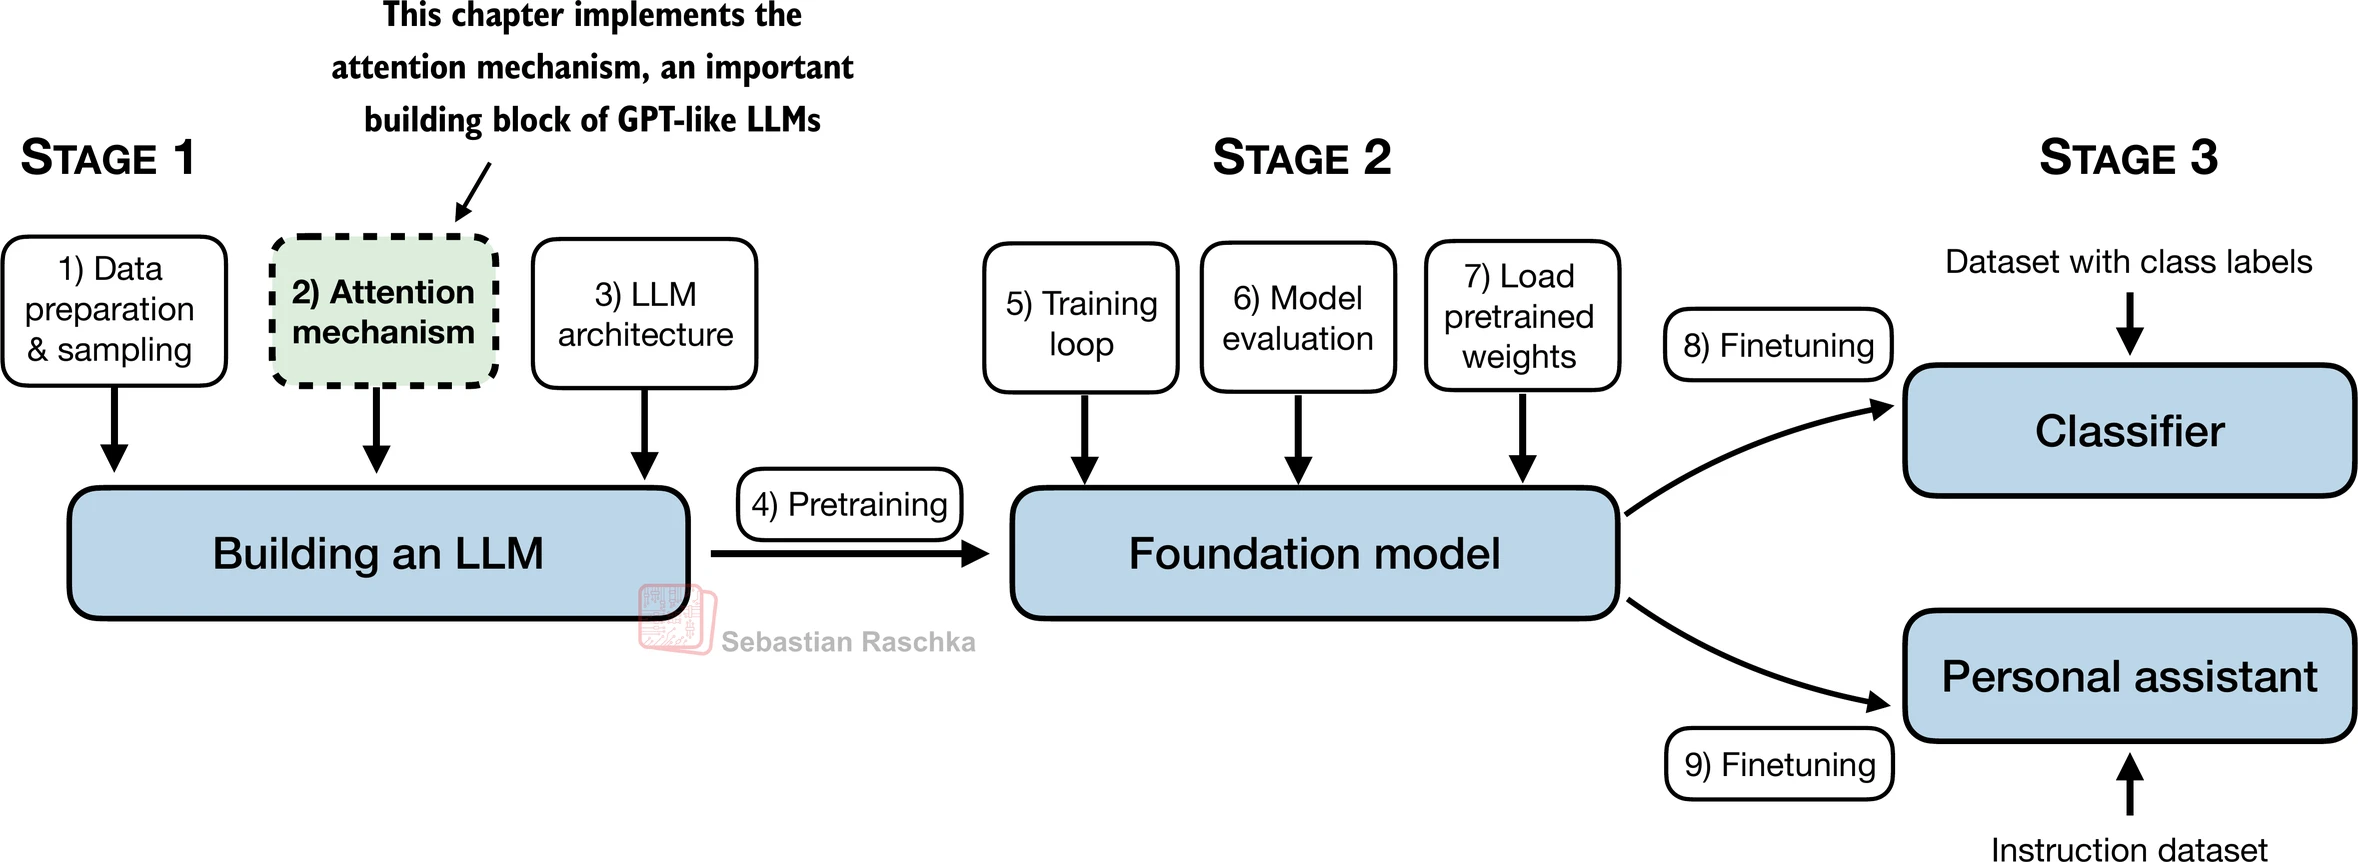

3.1 The problem with modeling long sequences

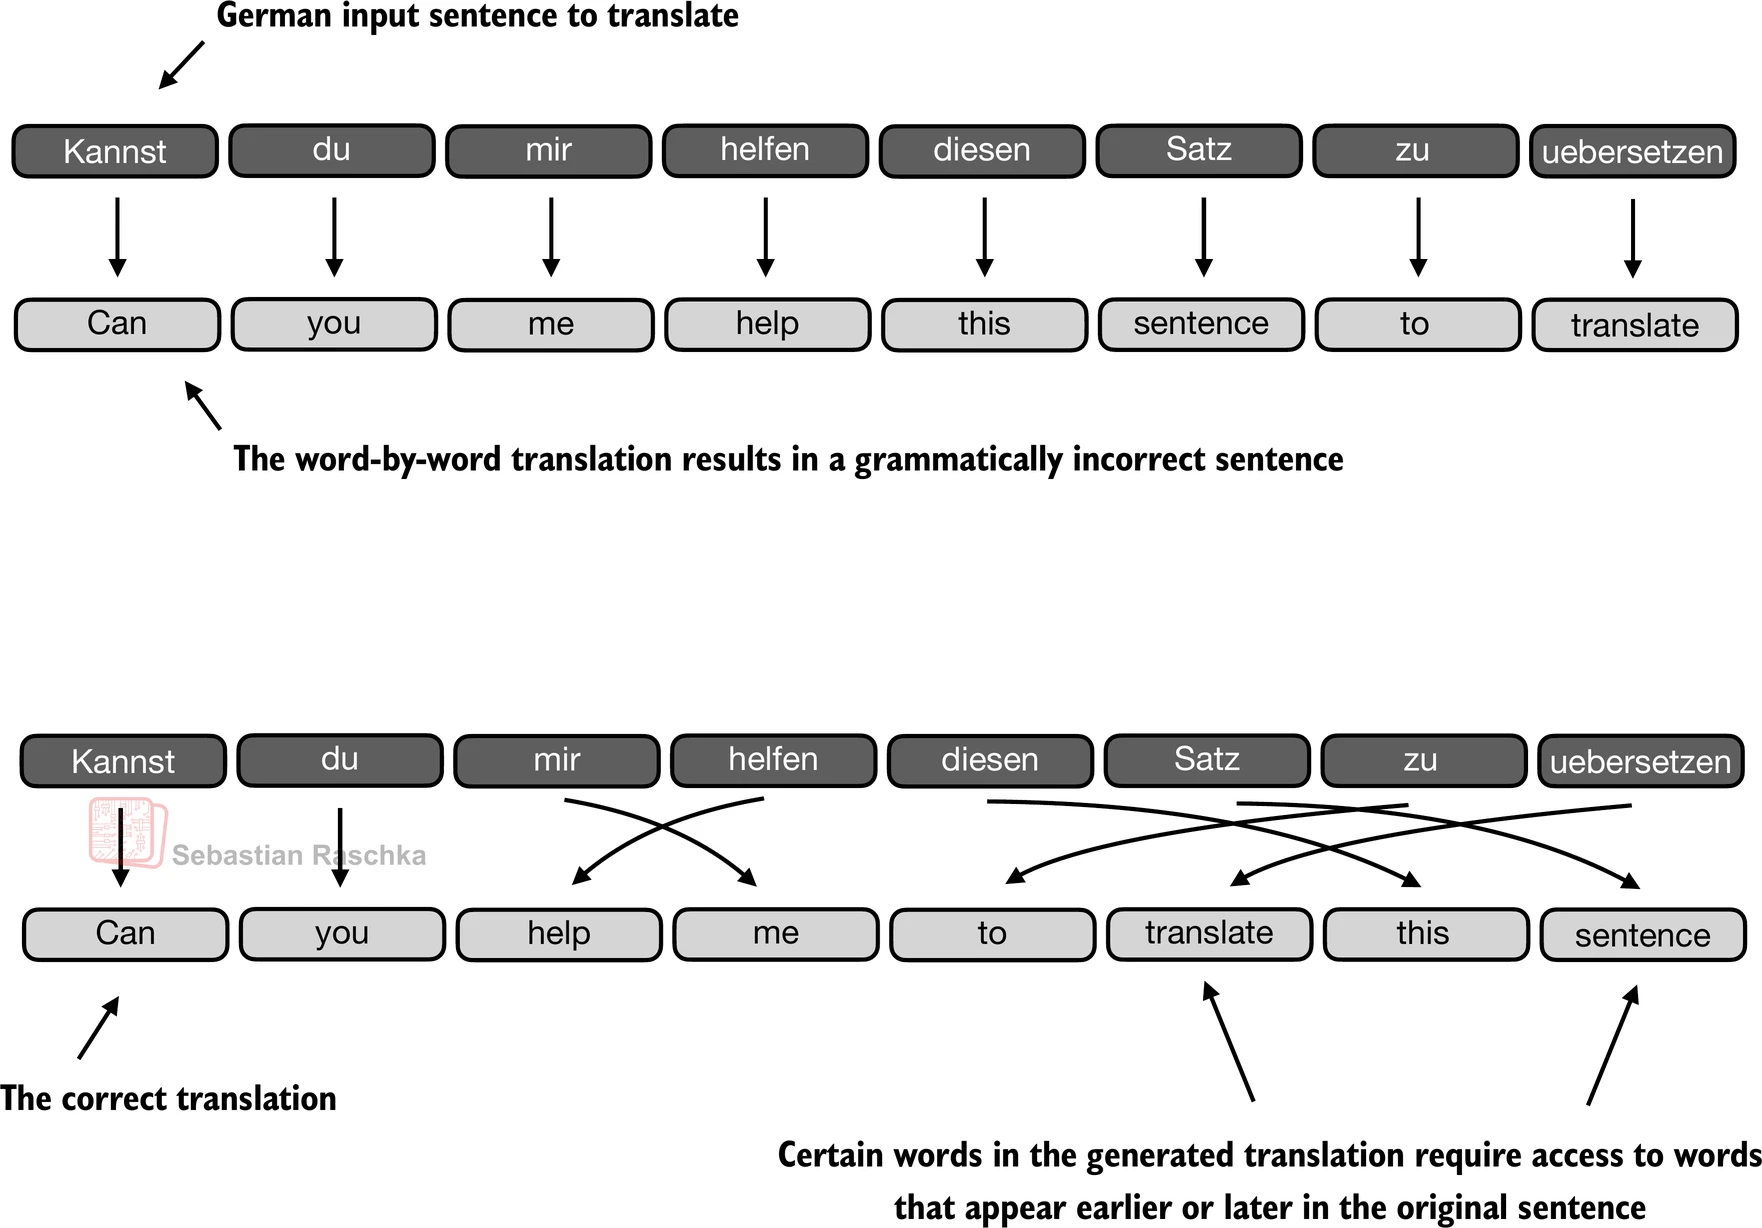

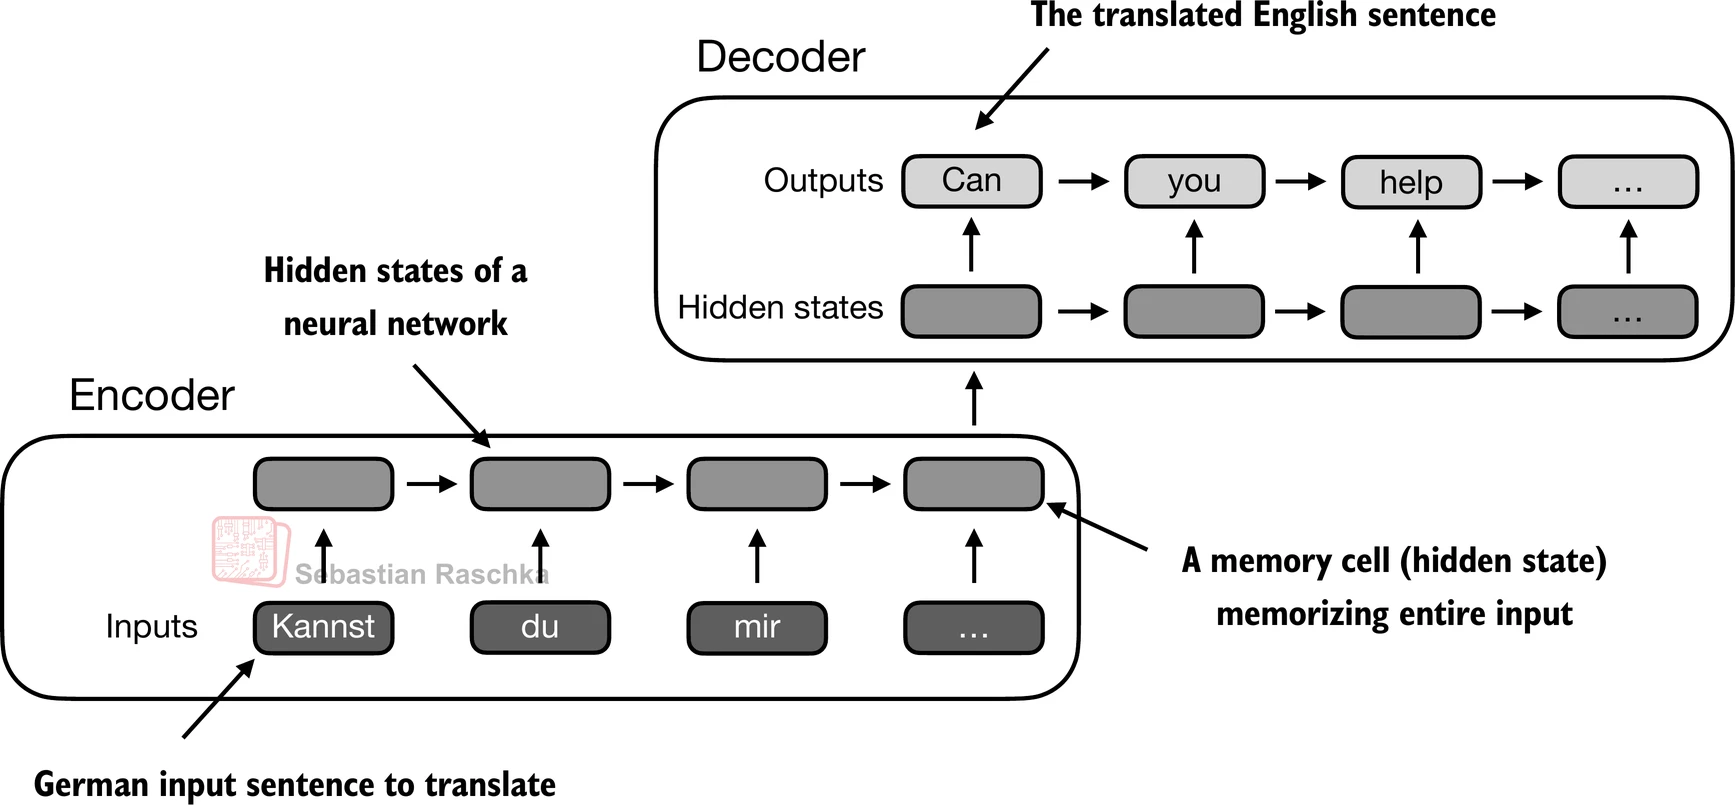

3.2 Capturing data dependencies with attention mechanisms

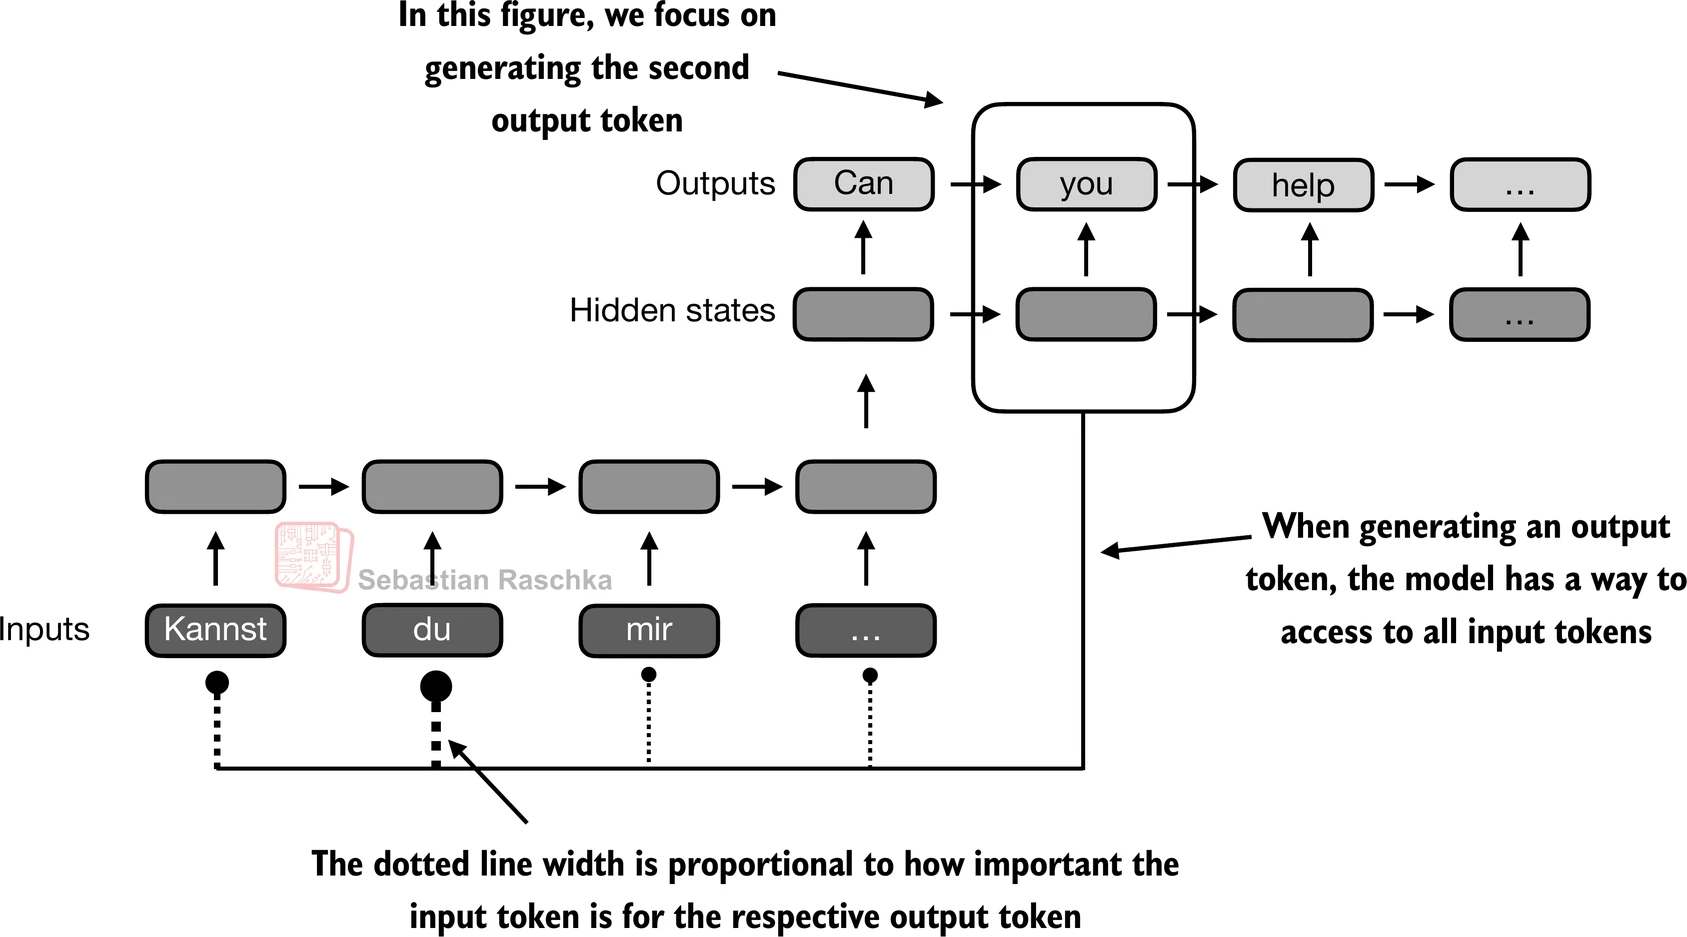

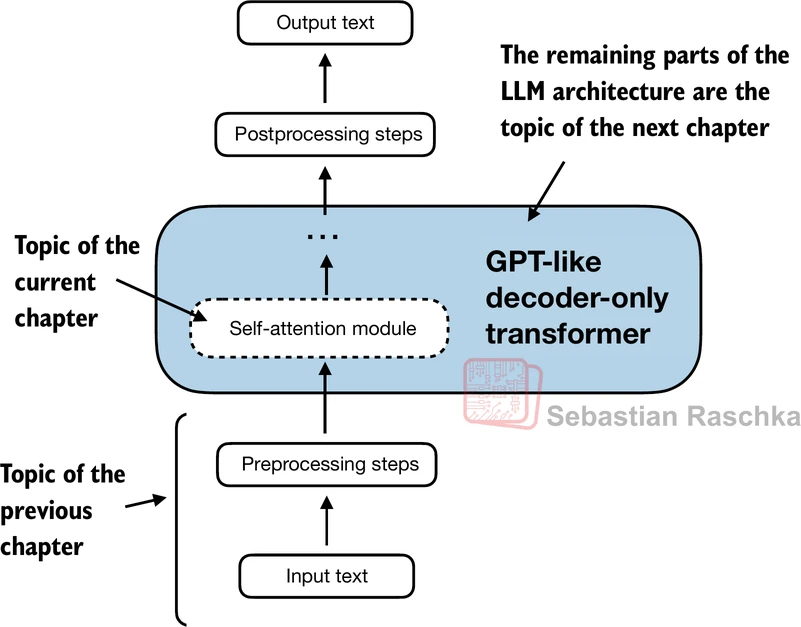

3.3 Attending to different parts of the input with self-attention


3.3.1 A simple self-attention mechanism without trainable weights
This section explains a very simplified variant of self-attention, which does not contain any trainable weights
This is purely for illustration purposes and NOT the attention mechanism that is used in transformers
The next section, section 3.3.2, will extend this simple attention mechanism to implement the real self-attention mechanism
Suppose we are given an input sequence
 to
The input is a text (for example, a sentence like "Your journey starts with one step") that has already been converted into token embeddings as described in chapter 2
For instance,
 is a d-dimensional vector representing the word "Your", and so forth
Goal: compute context vectors
 for each input sequence element
 in
 to
 (where
 and
 have the same dimension)
A context vector
 is a weighted sum over the inputs
 to
The context vector is "context"-specific to a certain input
Instead of
 as a placeholder for an arbitrary input token, let's consider the second input,
And to continue with a concrete example, instead of the placeholder
, we consider the second output context vector,
The second context vector,
, is a weighted sum over all inputs
 to
 weighted with respect to the second input element,
The attention weights are the weights that determine how much each of the input elements contributes to the weighted sum when computing
In short, think of
 as a modified version of
 that also incorporates information about all other input elements that are relevant to a given task at hand

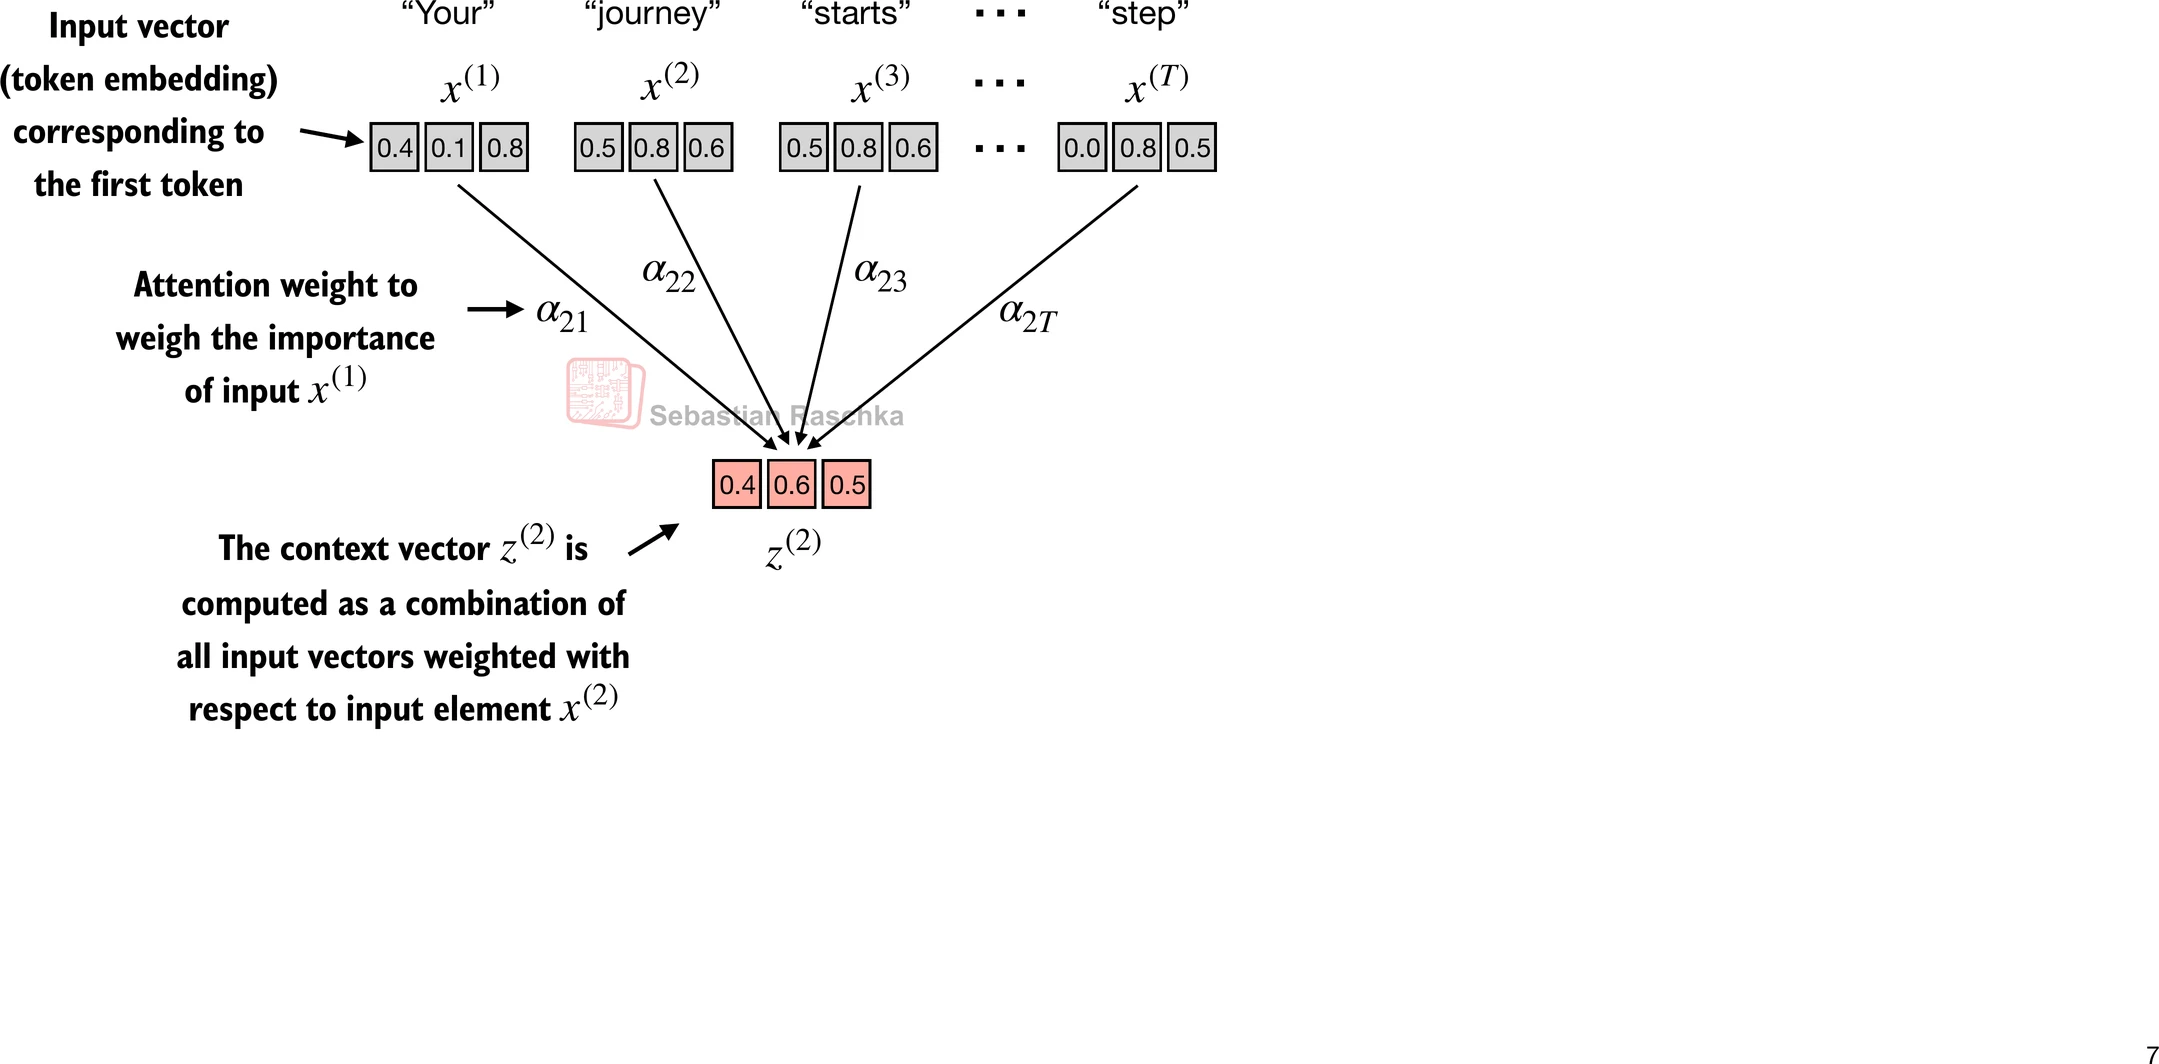

(Please note that the numbers in this figure are truncated to one digit after the decimal point to reduce visual clutter; similarly, other figures may also contain truncated values)
By convention, the unnormalized attention weights are referred to as "attention scores" whereas the normalized attention scores, which sum to 1, are referred to as "attention weights"
The code below walks through the figure above step by step

Step 1: compute unnormalized attention scores
Suppose we use the second input token as the query, that is,
, we compute the unnormalized attention scores via dot products:
...
Above,
 is the Greek letter "omega" used to symbolize the unnormalized attention scores
The subscript "21" in
 means that input sequence element 2 was used as a query against input sequence element 1
Suppose we have the following input sentence that is already embedded in 3-dimensional vectors as described in chapter 3 (we use a very small embedding dimension here for illustration purposes, so that it fits onto the page without line breaks):

In [ ]:
import torch

# 构造一个形状为 (6, 3) 的输入嵌入矩阵：6 个 token（"Your journey starts with one step"），
# 每个 token 用一个 3 维向量表示（真实场景中嵌入维度通常远大于 3，这里为了方便手算演示）
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

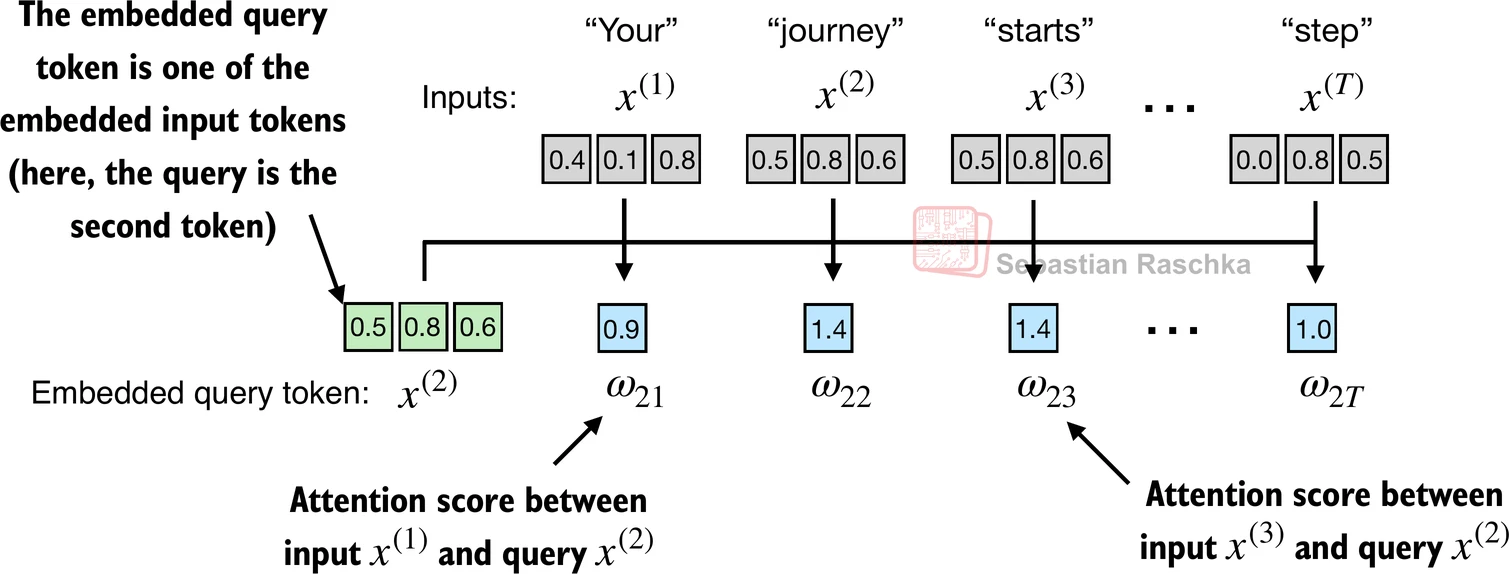

In [ ]:
# 以第 2 个 token（journey, x^2）作为 query，计算它与所有输入向量的点积，
# 得到未归一化的注意力分数（attention scores），形状为 (6,)
query=inputs[1]
attn_scores_2=torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

In [ ]:
# 手动展开点积运算，验证与 torch.dot 结果一致：
# 逐元素相乘再求和，等价于 inputs[0] 与 query 的点积
res = 0.

for idx, element in enumerate(inputs[0]):
    res += inputs[0][idx] * query[idx]

print(res)
print(torch.dot(inputs[0], query))

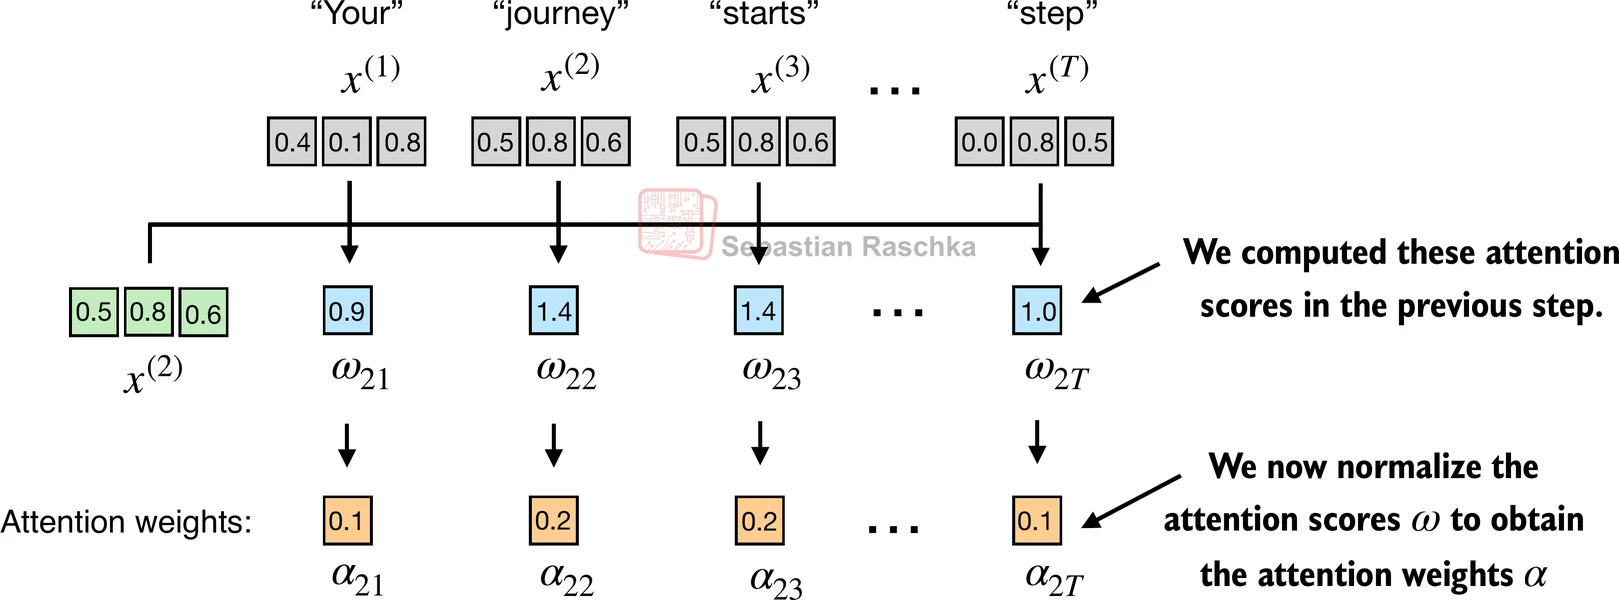

In [ ]:
# 简单归一化：将每个注意力分数除以总和，使权重加起来等于 1（不是标准 softmax）
attn_weights_2_tmp=attn_scores_2/attn_scores_2.sum()
print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

In [ ]:
# 手写 softmax 实现：exp 后按维度 0 求和归一化
# 相比上面的简单归一化，softmax 能更好地处理负数分数，并放大较大分数之间的差距
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

In [ ]:
# 使用 PyTorch 内置的 softmax，数值上更稳定（内部做了减最大值等技巧，避免溢出）
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

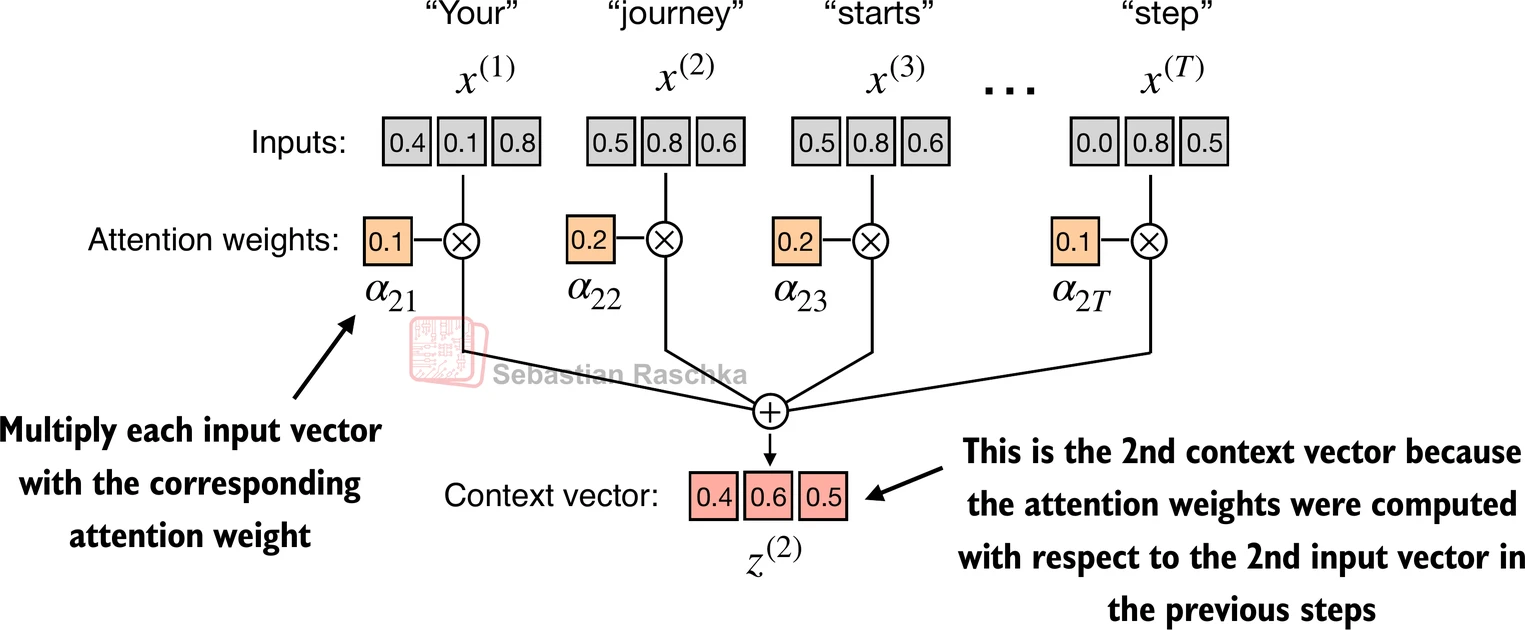

In [ ]:
# 计算 query（x^2）对应的上下文向量（context vector）：
# 用每个输入向量按其注意力权重加权求和
# [BUG FIX] 原代码为 torch.zero_(query.shape)：torch.zero_ 是原地(in-place)操作，只能作用于已有 Tensor，
# 传入 torch.Size 会报 TypeError；这里改为 torch.zeros(query.shape) 生成一个同形状的全零张量作为累加器
query=inputs[1]
context_vec_2=torch.zeros(query.shape)
for i ,x_i in enumerate(inputs):
    context_vec_2+=attn_weights_2[i]*x_i
print(context_vec_2)

3.3.2 Computing attention weights for all input tokens

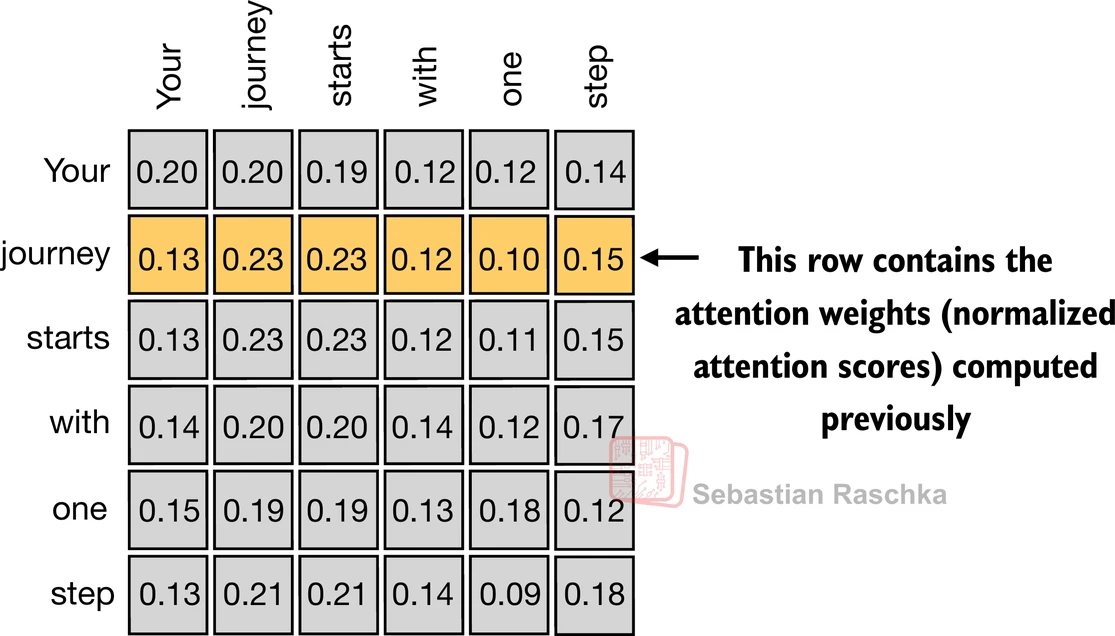

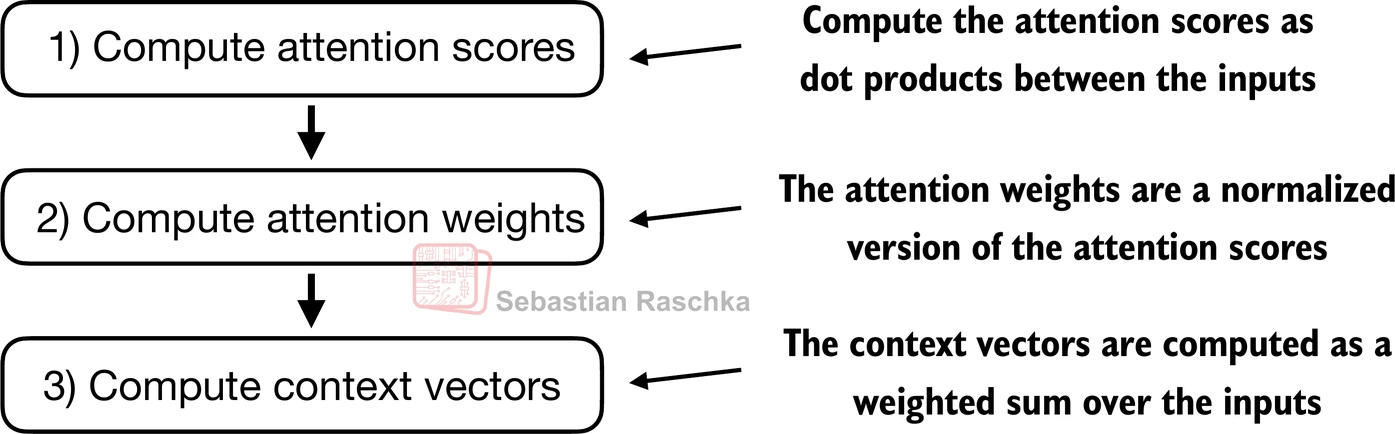

In [ ]:
# 对所有 token 两两计算点积，得到完整的注意力分数矩阵，形状为 (6, 6)
# 这里用双重循环实现，直观但效率较低（仅用于教学演示）
attn_scores=torch.empty(6,6)
for i ,x_i in enumerate(inputs):
    for j,x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)

In [ ]:
# 用矩阵乘法一次性计算所有 token 两两之间的点积，等价于上面的双重循环，但更高效
# inputs: (6, 3) @ inputs.T: (3, 6) -> attn_scores: (6, 6)
attn_scores = inputs @ inputs.T
print(attn_scores)

In [ ]:
# 对每一行（dim=-1，即每个 query 对所有 key 的分数）做 softmax，得到归一化的注意力权重矩阵 (6, 6)
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

In [ ]:
# 验证：第 2 行的注意力权重之和应约等于 1
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)

# 验证所有行的权重和均为 1（softmax 的性质）
print("All row sums:", attn_weights.sum(dim=-1))

In [ ]:
# 用注意力权重矩阵对输入向量做加权求和，一次性得到所有 token 的上下文向量
# attn_weights: (6, 6) @ inputs: (6, 3) -> all_context_vecs: (6, 3)
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

In [ ]:
# 对比之前单独计算的第 2 个 token 的上下文向量，应与 all_context_vecs 的第 2 行一致
print("Previous 2nd context vector:", context_vec_2)

3.4 Implementing self-attention with trainable weights

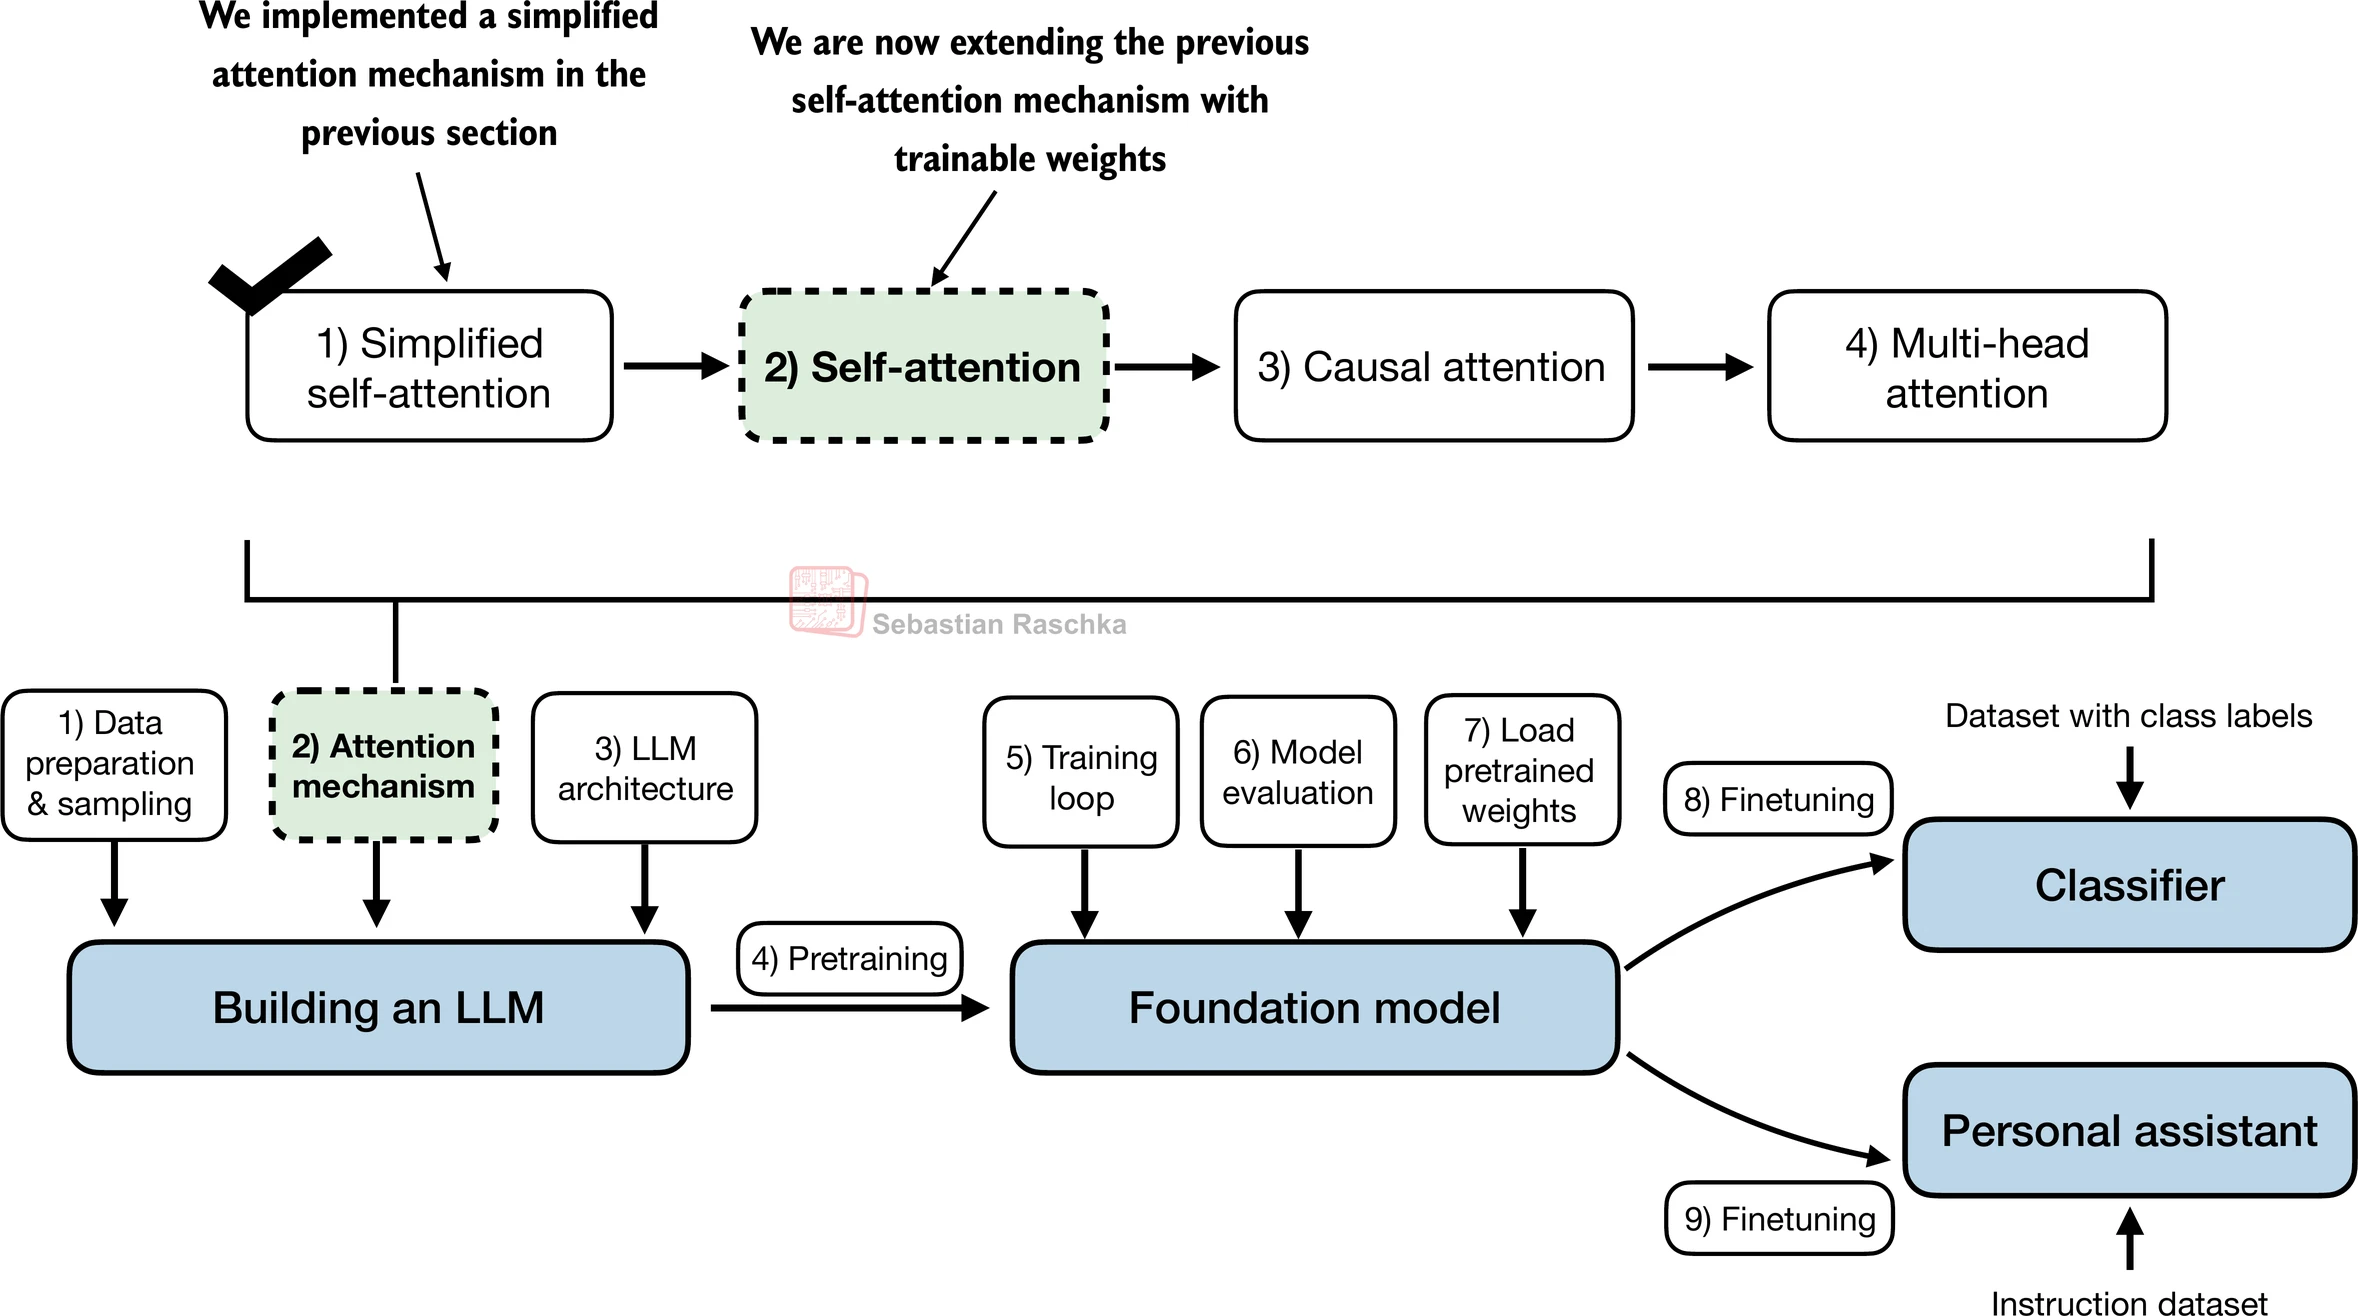

3.4.1 Computing the attention weights step by step

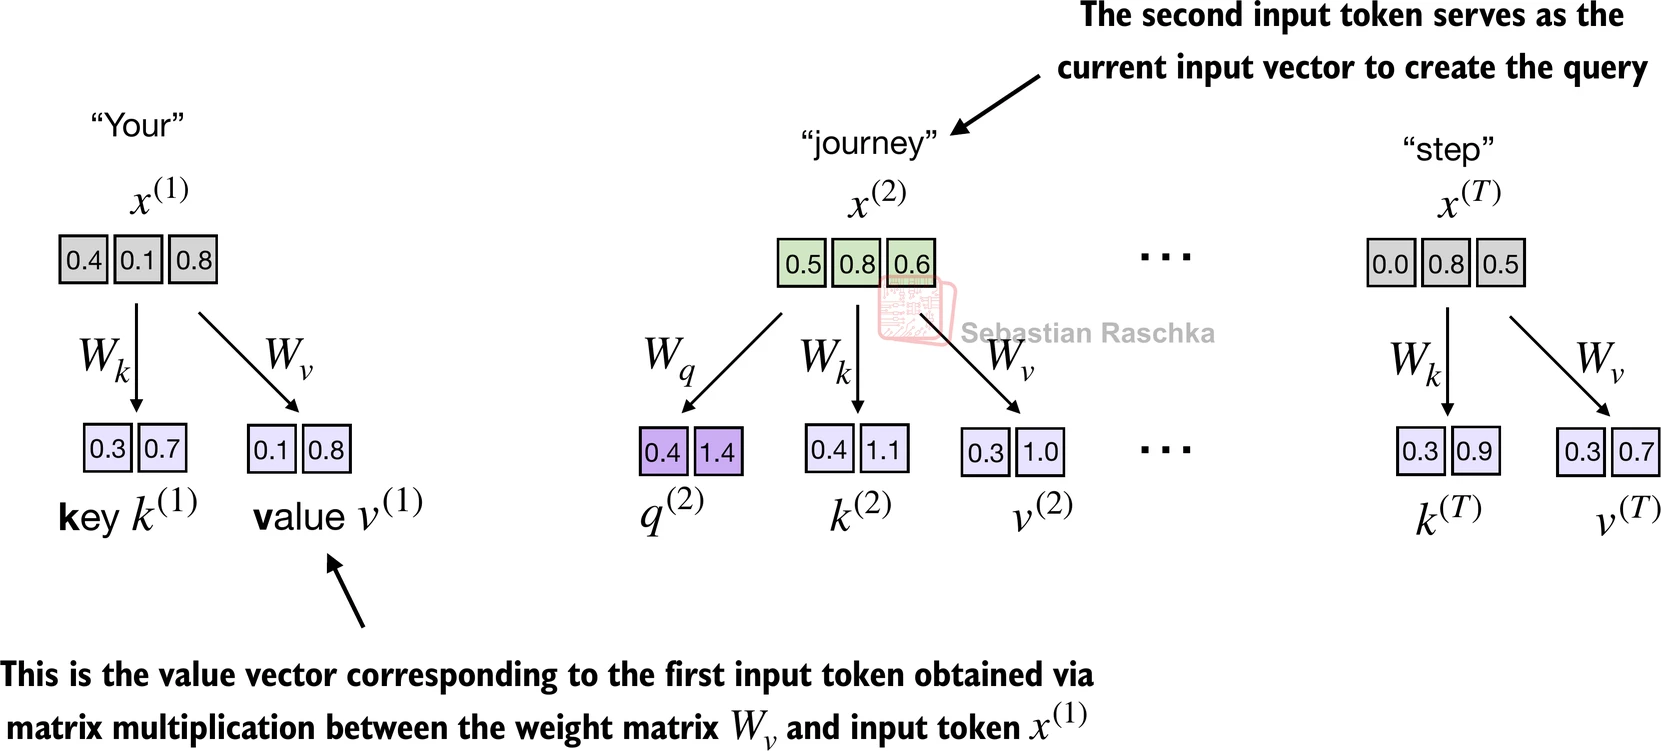

In [ ]:
# 定义可训练自注意力所需的维度：
# d_in  = 输入嵌入维度（这里为 3）
# d_out = 输出（Q/K/V 投影后）维度，可以与 d_in 不同，这里设为 2 便于演示
x_2 = inputs[1] # second input element
d_in = inputs.shape[1] # the input embedding size, d=3
d_out = 2 # the output embedding size, d=2

In [ ]:
# 初始化 Query / Key / Value 三个可训练权重矩阵，形状均为 (d_in, d_out)
# 这里用 requires_grad=False 仅作演示，实际训练时应设为 True 以便反向传播更新
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [ ]:
# 用输入向量 x_2 (维度 d_in=3) 分别乘以三个权重矩阵，得到该 token 的 query/key/value 向量（维度 d_out=2）
query_2 = x_2 @ W_query # _2 because it's with respect to the 2nd input element
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

print(query_2)

In [ ]:
# 对全部输入一次性做矩阵乘法，得到所有 token 的 key 和 value：
# inputs: (6, 3) @ W_key/W_value: (3, 2) -> keys/values: (6, 2)
keys = inputs @ W_key
values = inputs @ W_value

print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

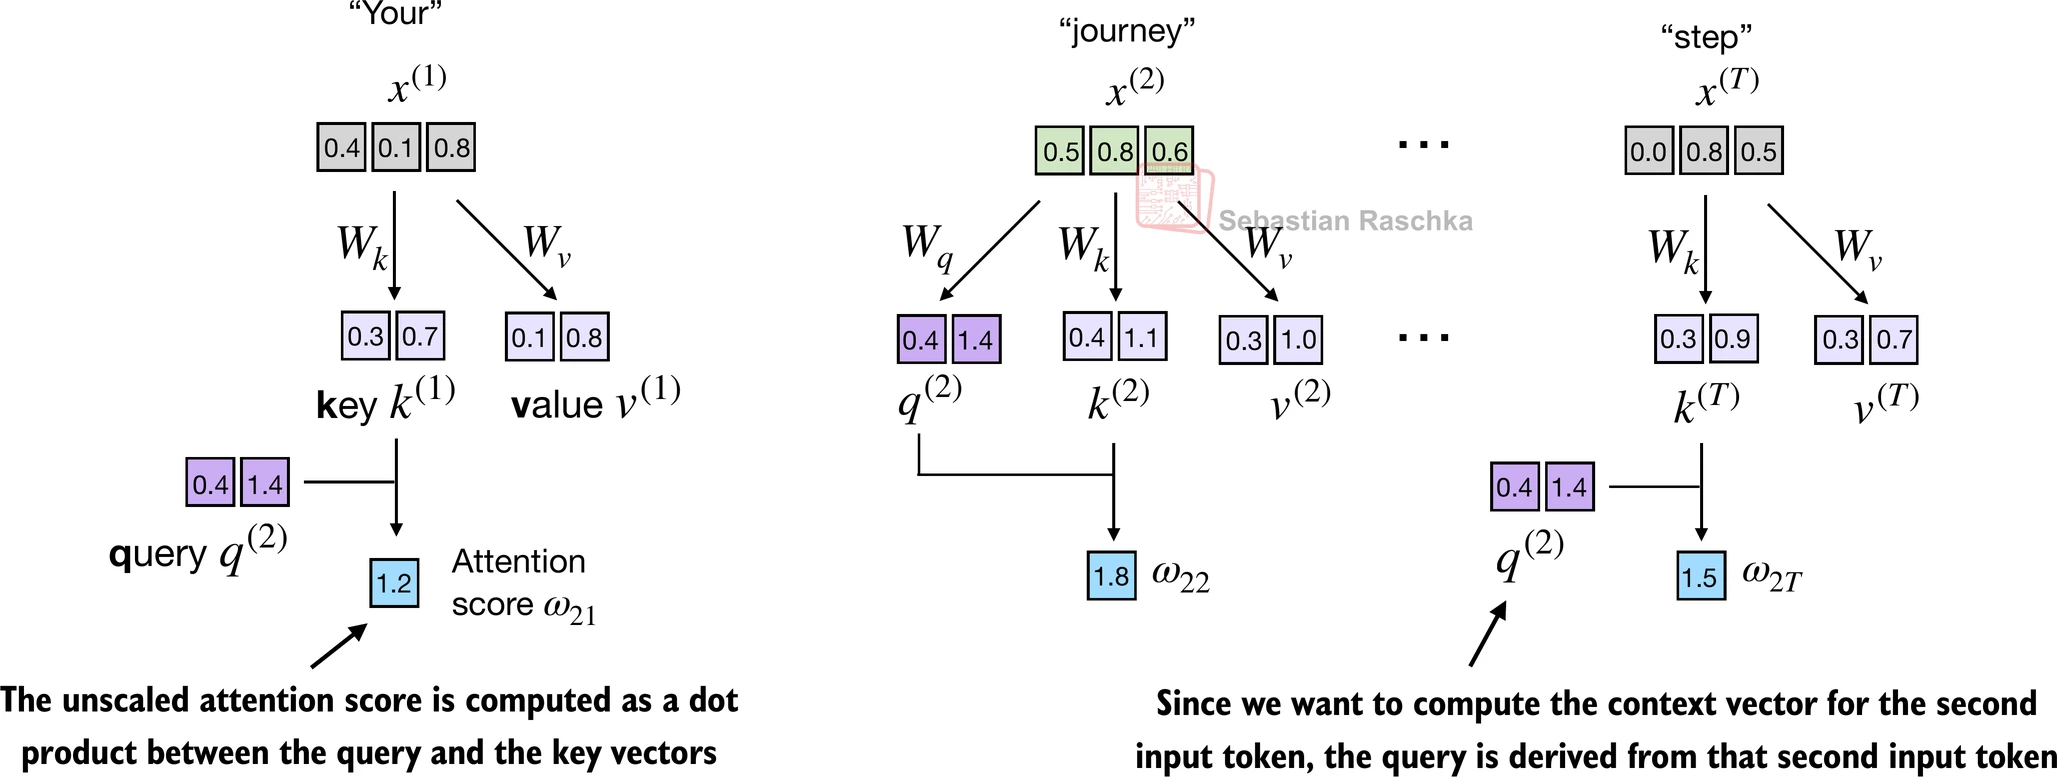

In [ ]:
# 计算 query_2 与第 2 个 token 的 key（keys_2）之间的注意力分数（标量）
keys_2 = keys[1] # Python starts index at 0
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

In [ ]:
# 将 query_2 与所有 token 的 key 做点积，得到 query_2 对全部 6 个 token 的注意力分数，形状为 (6,)
# query_2: (2,) @ keys.T: (2, 6) -> attn_scores_2: (6,)
attn_scores_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

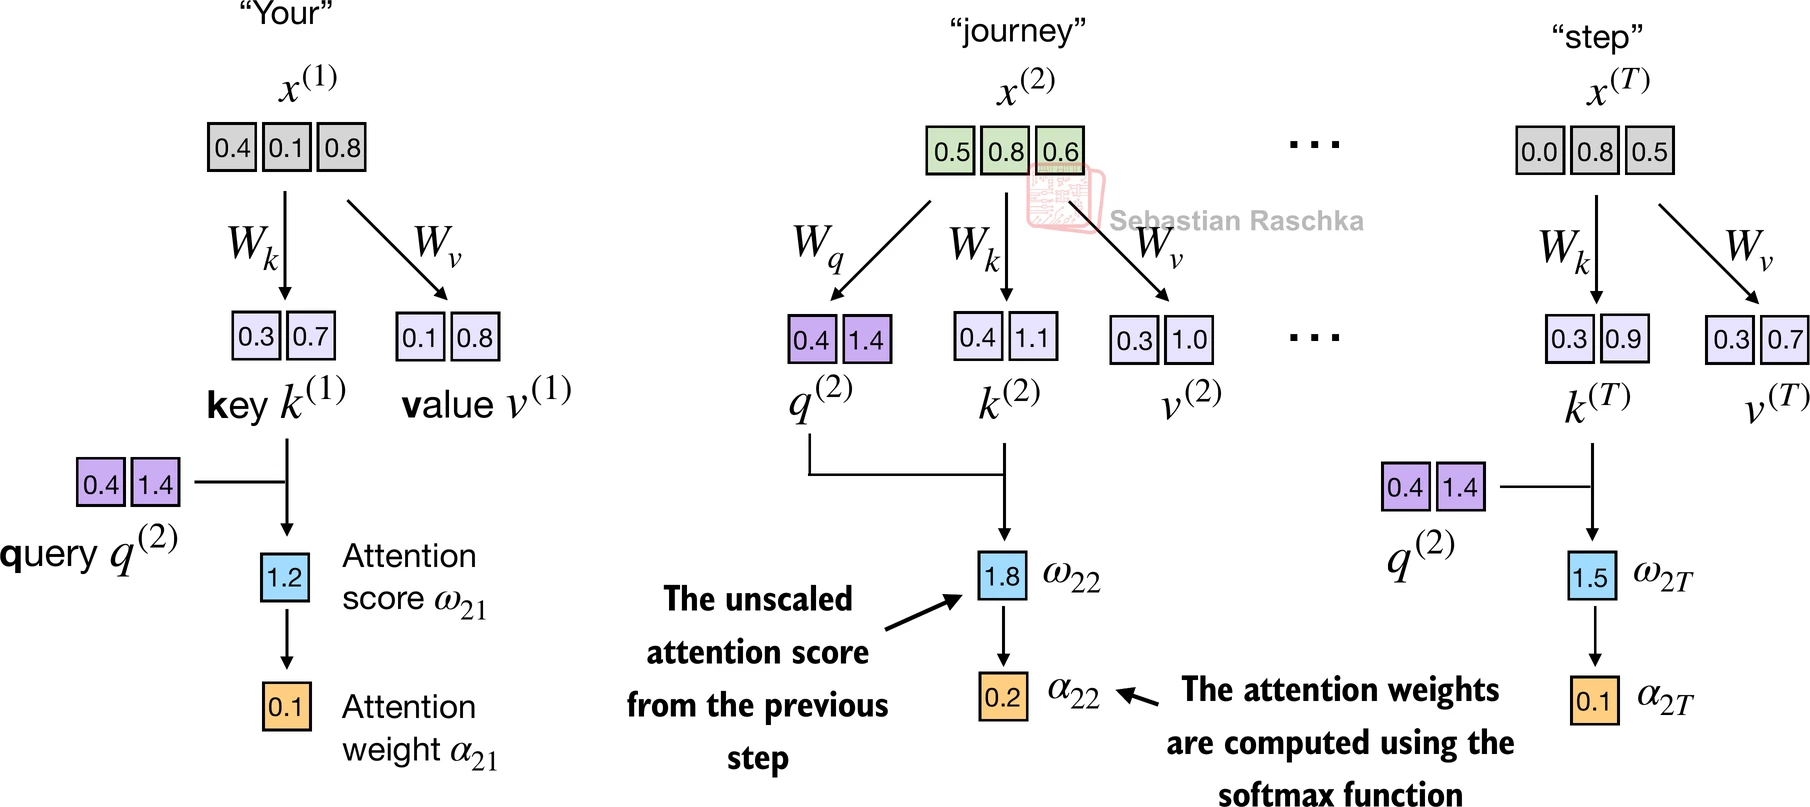

In [ ]:
# 缩放点积注意力（scaled dot-product attention）：
# 除以 sqrt(d_k) 再做 softmax，可以避免当 d_k 较大时点积数值过大导致 softmax 梯度过小（过于陡峭）
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

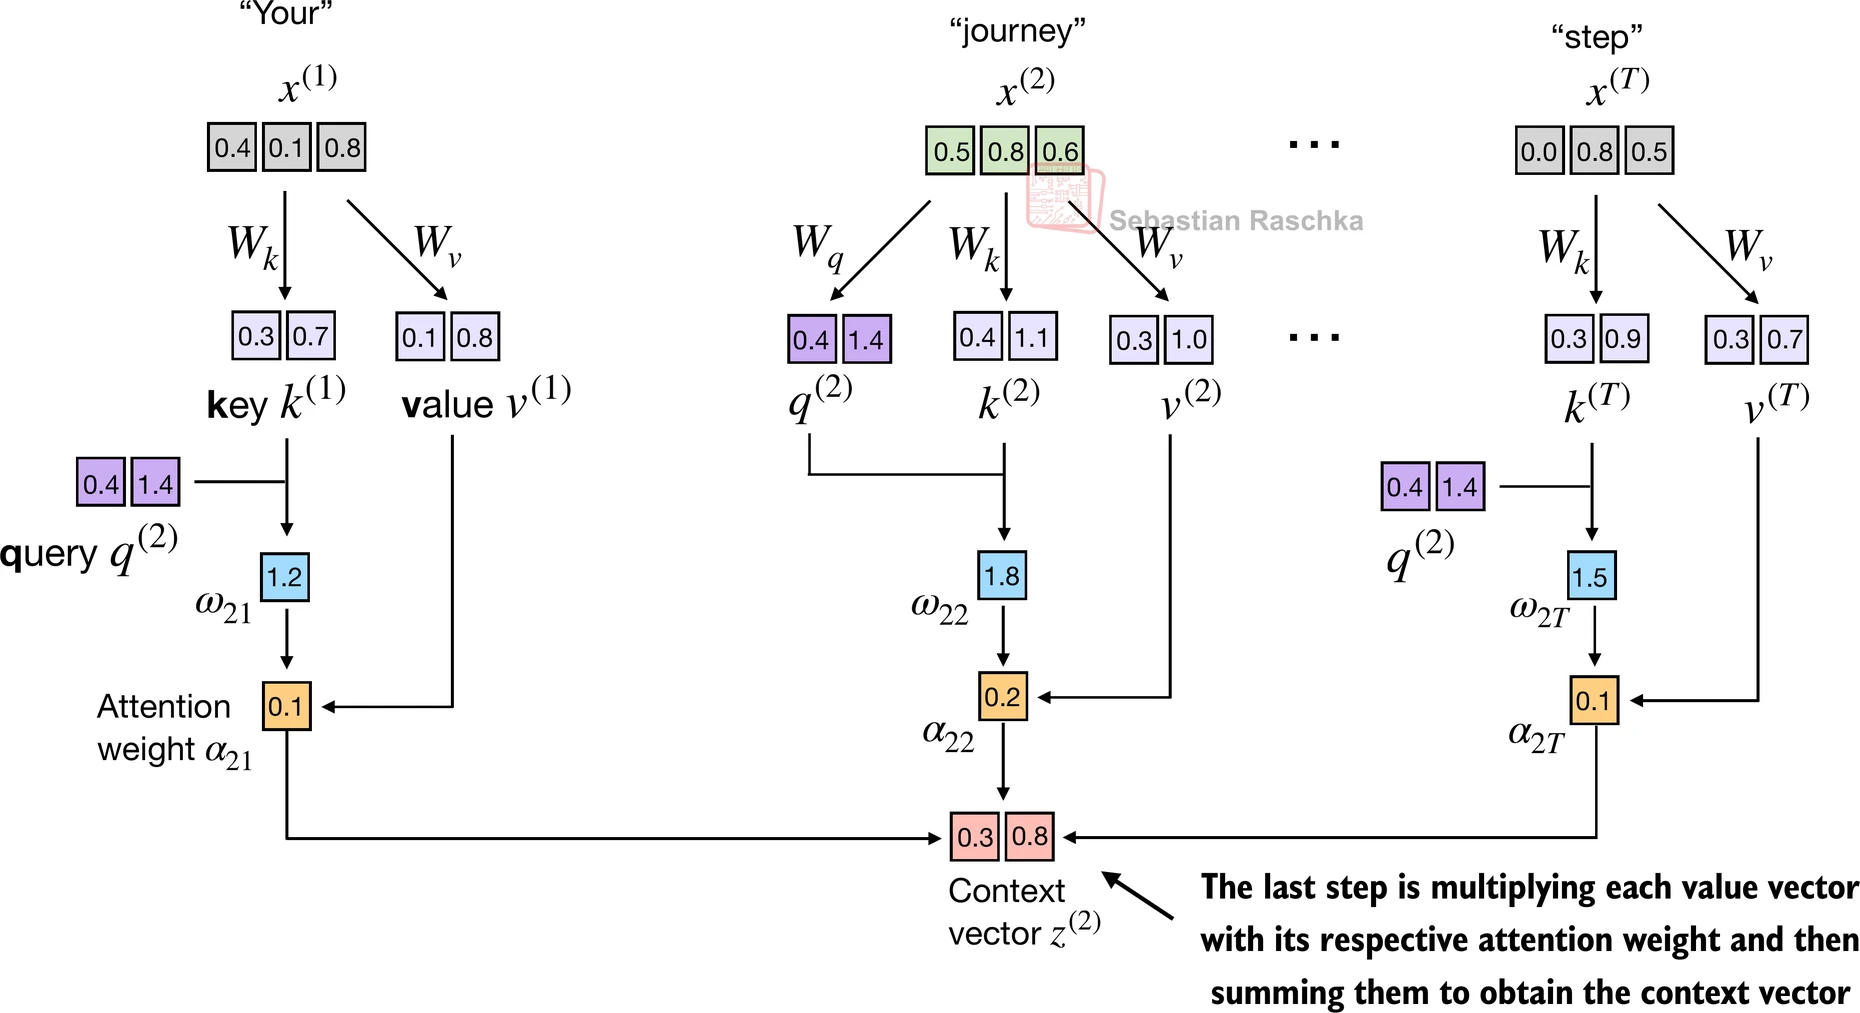

In [ ]:
# 用注意力权重对所有 value 向量做加权求和，得到 query_2 对应的上下文向量
# attn_weights_2: (6,) @ values: (6, 2) -> context_vec_2: (2,)
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

3.4.2 Implementing a compact SelfAttention class

In [ ]:
import torch.nn as nn

# 将上面手写的自注意力流程封装成一个 nn.Module，方便复用
class SelfAttention_v1(nn.Module):

    def __init__(self, d_in, d_out):
        super().__init__()
        # Q/K/V 权重矩阵，形状均为 (d_in, d_out)
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        # x: (num_tokens, d_in) -> keys/queries/values: (num_tokens, d_out)
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value

        # queries: (num_tokens, d_out) @ keys.T: (d_out, num_tokens) -> attn_scores: (num_tokens, num_tokens)
        attn_scores = queries @ keys.T # omega
        # 缩放点积后做 softmax，得到归一化的注意力权重 (num_tokens, num_tokens)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        # attn_weights: (num_tokens, num_tokens) @ values: (num_tokens, d_out) -> context_vec: (num_tokens, d_out)
        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

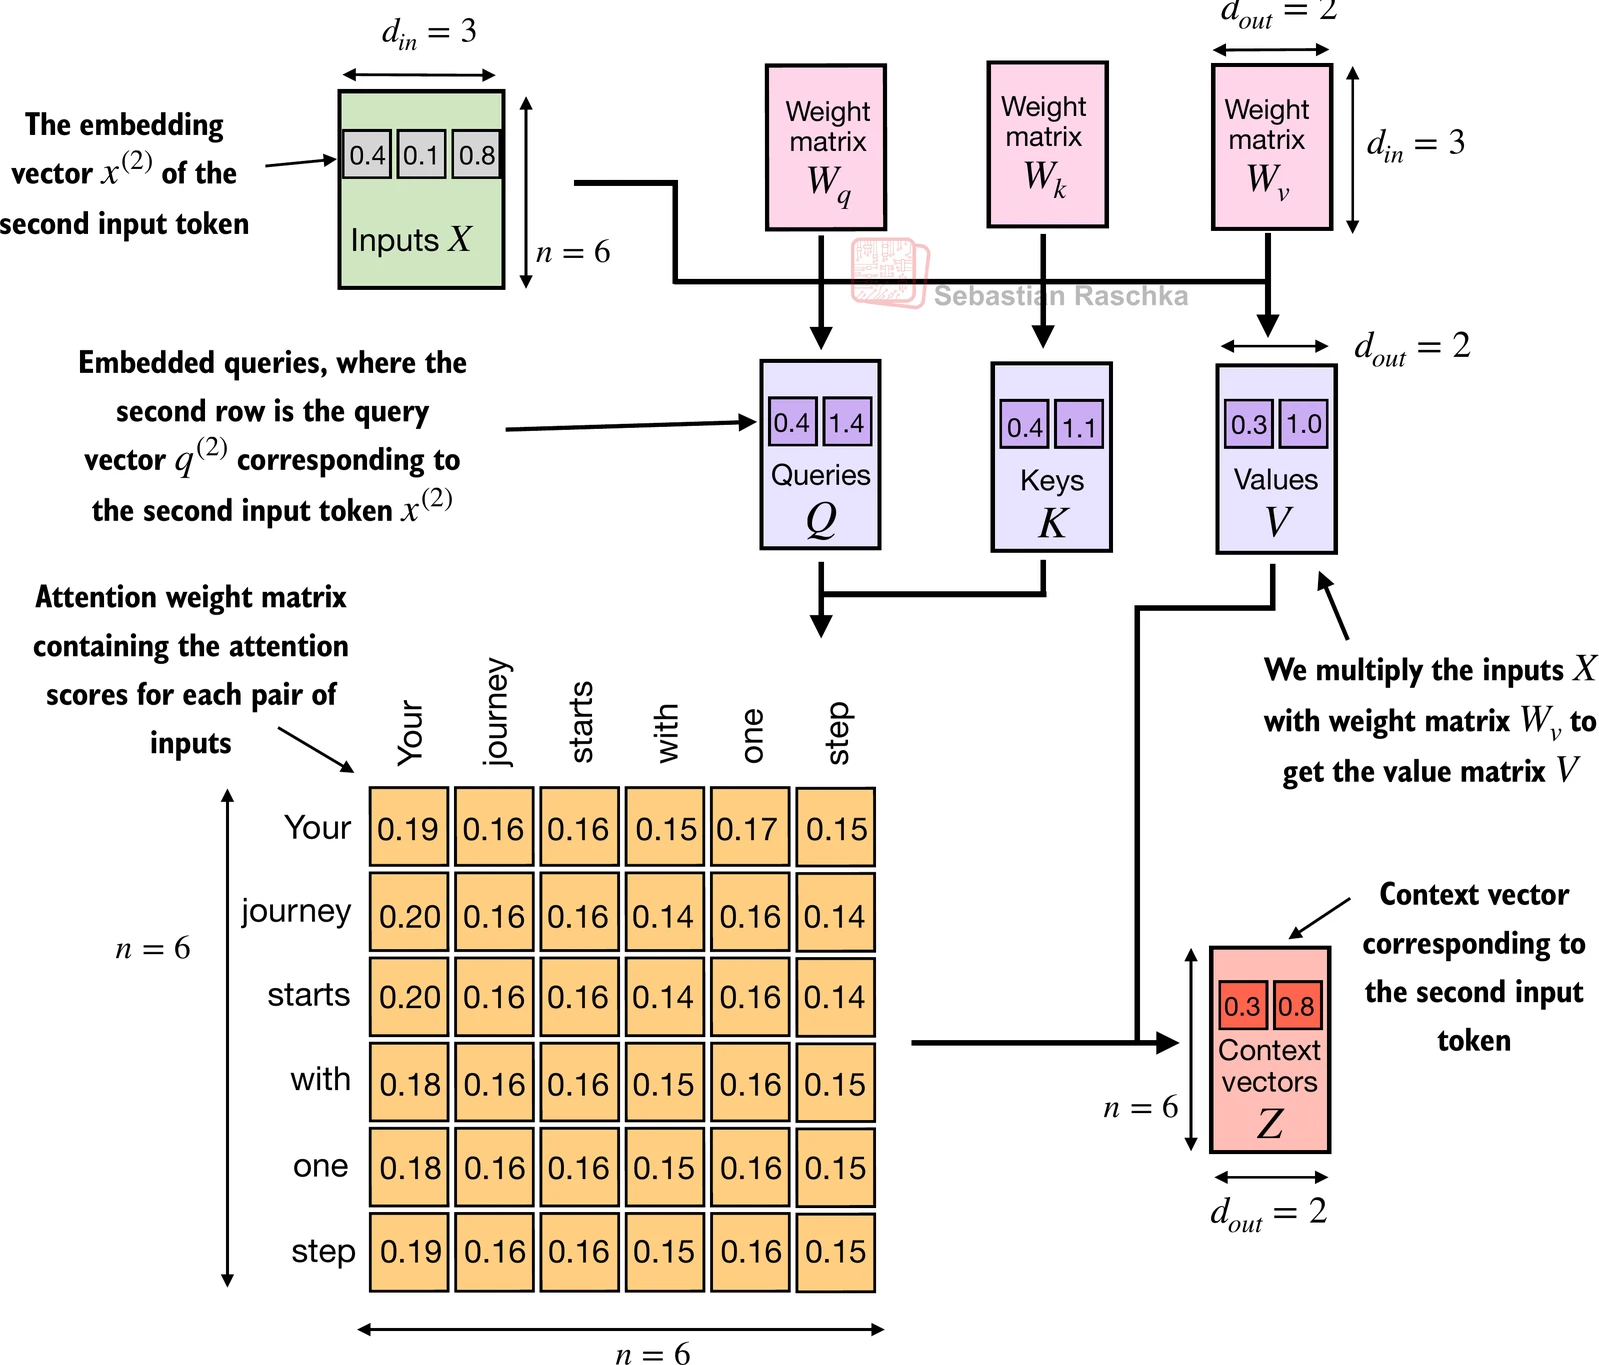

In [ ]:
# 改进版：用 nn.Linear 代替手写的权重矩阵来实现 Q/K/V 投影，
# 效果等价（本质上也是 x @ W + b），但可以利用 PyTorch 更优的参数初始化方式，且方便加偏置项 qkv_bias
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

3.5 Hiding future words with causal attention
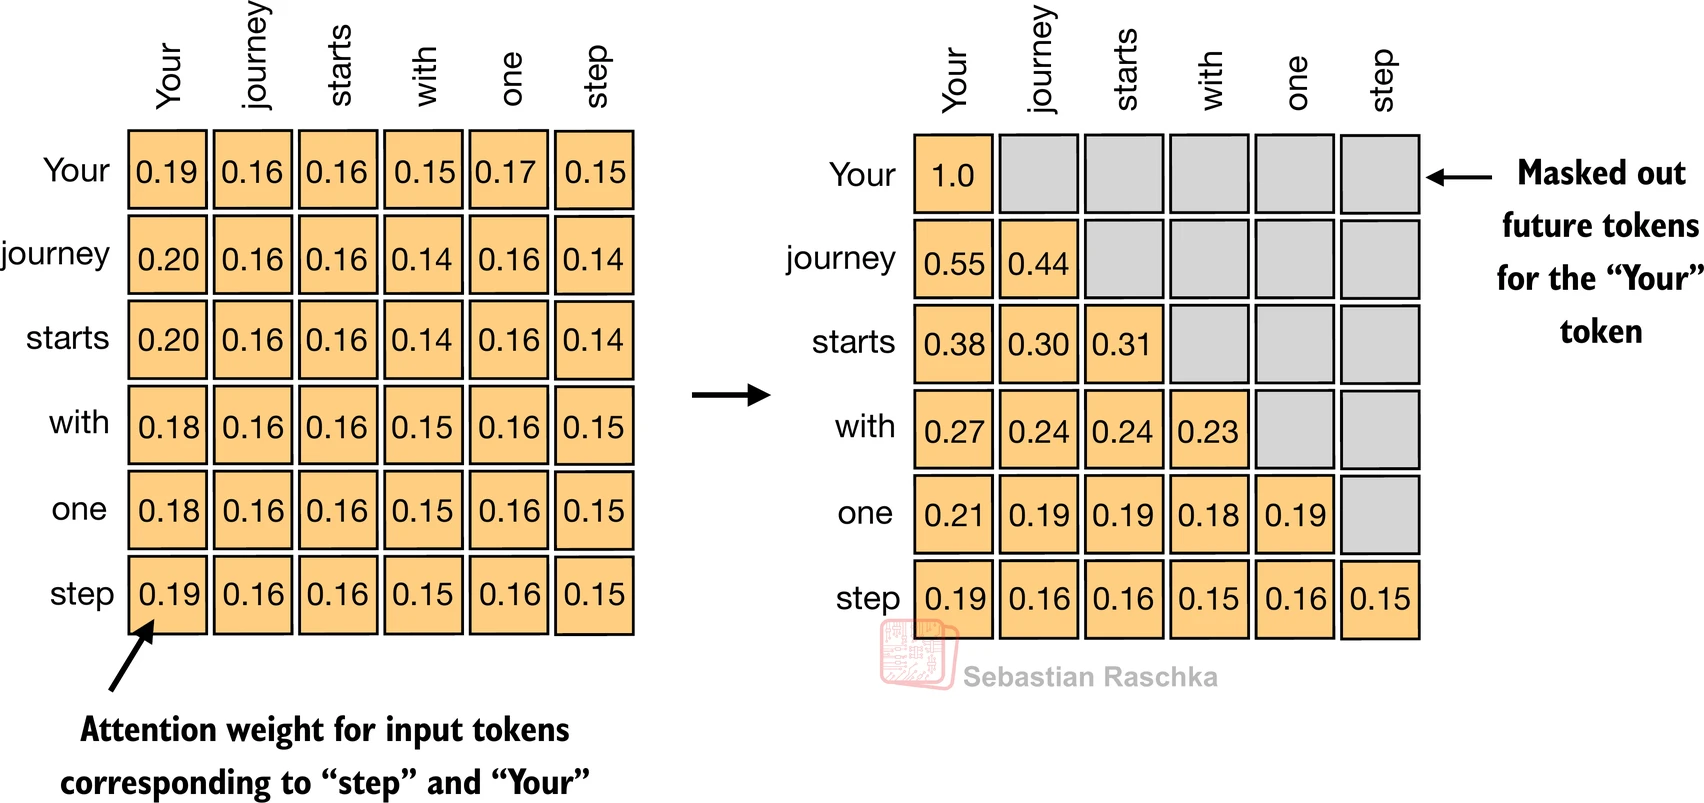

3.5.1 Applying a causal attention mask
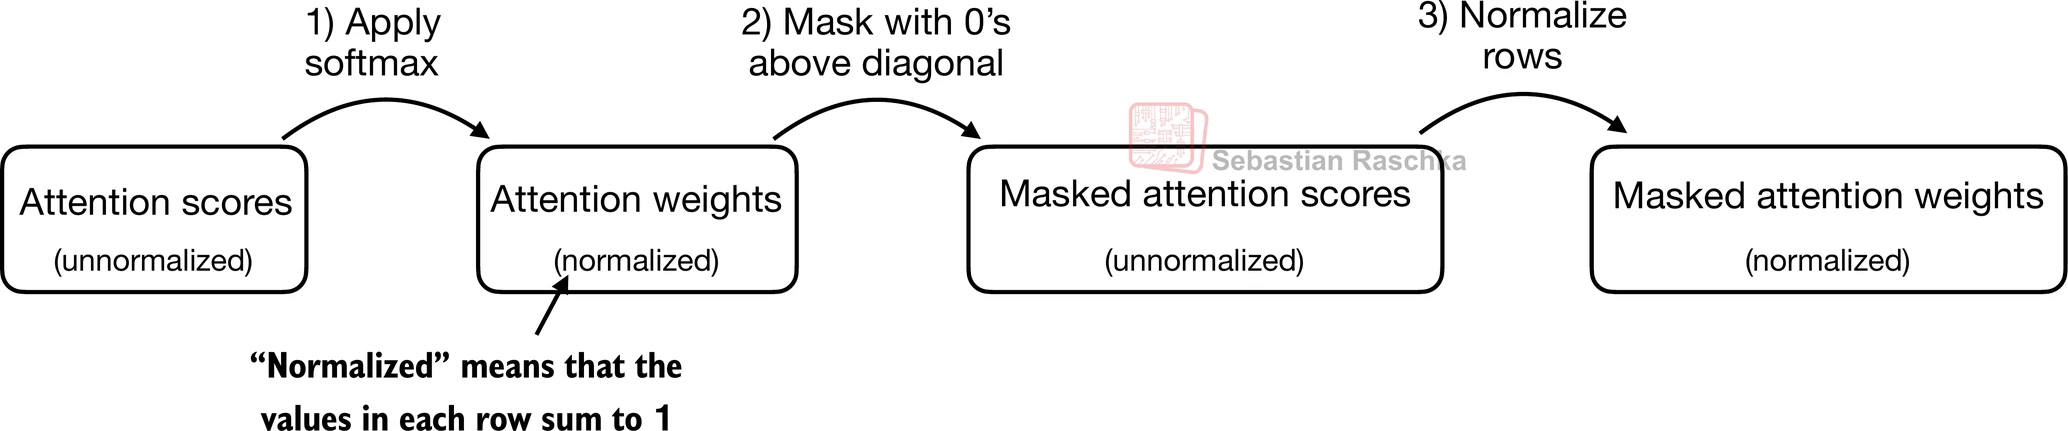

In [ ]:
# Reuse the query and key weight matrices of the
# SelfAttention_v2 object from the previous section for convenience
# 复用 v2 的权重，重新计算一遍未加掩码的 queries/keys/attn_scores/attn_weights，
# 为下面演示因果掩码（causal mask）做准备
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

In [ ]:
# 构造因果掩码（causal mask）：下三角矩阵（含对角线）为 1，上三角为 0，
# 用来保证每个位置只能看到自己及之前的 token，看不到未来的 token
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

In [ ]:
# 朴素做法：直接将注意力权重与掩码逐元素相乘，把未来位置的权重置为 0
# 注意：此时每一行的权重之和不再是 1，需要后续重新归一化
masked_simple = attn_weights*mask_simple
print(masked_simple)

In [ ]:
# 按行重新归一化，使掩码后的每一行权重之和恢复为 1
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

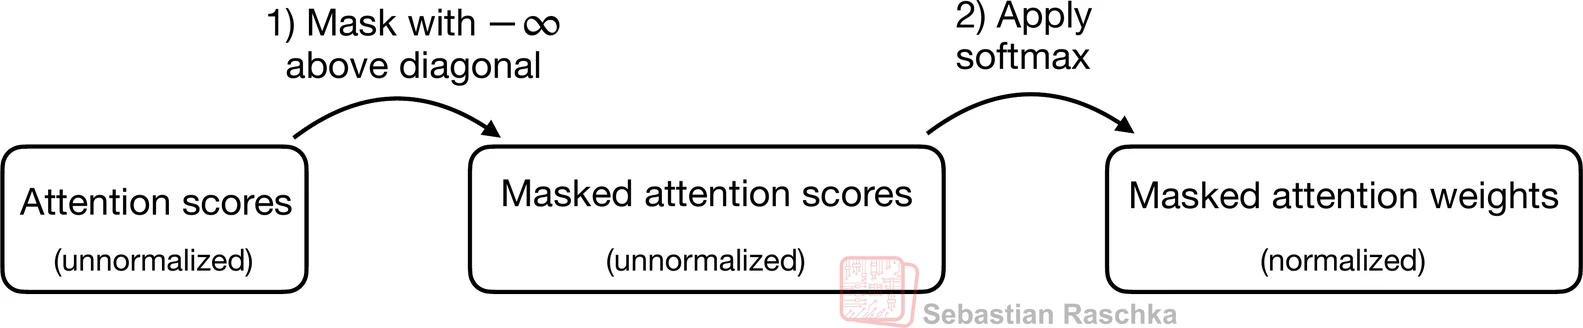

In [ ]:
# 更高效、更标准的做法：在 softmax 之前，用 -inf 填充未来位置的注意力分数，
# 这样 softmax 后这些位置自动变为 0，且无需额外的归一化步骤
# mask 为上三角（不含对角线）矩阵，标记出所有"未来"位置
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

In [ ]:
# 对填充了 -inf 的分数做缩放 + softmax：exp(-inf) = 0，
# 因此未来位置的权重自动为 0，且每行权重和天然为 1
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

3.5.2 Masking additional attention weights with dropout
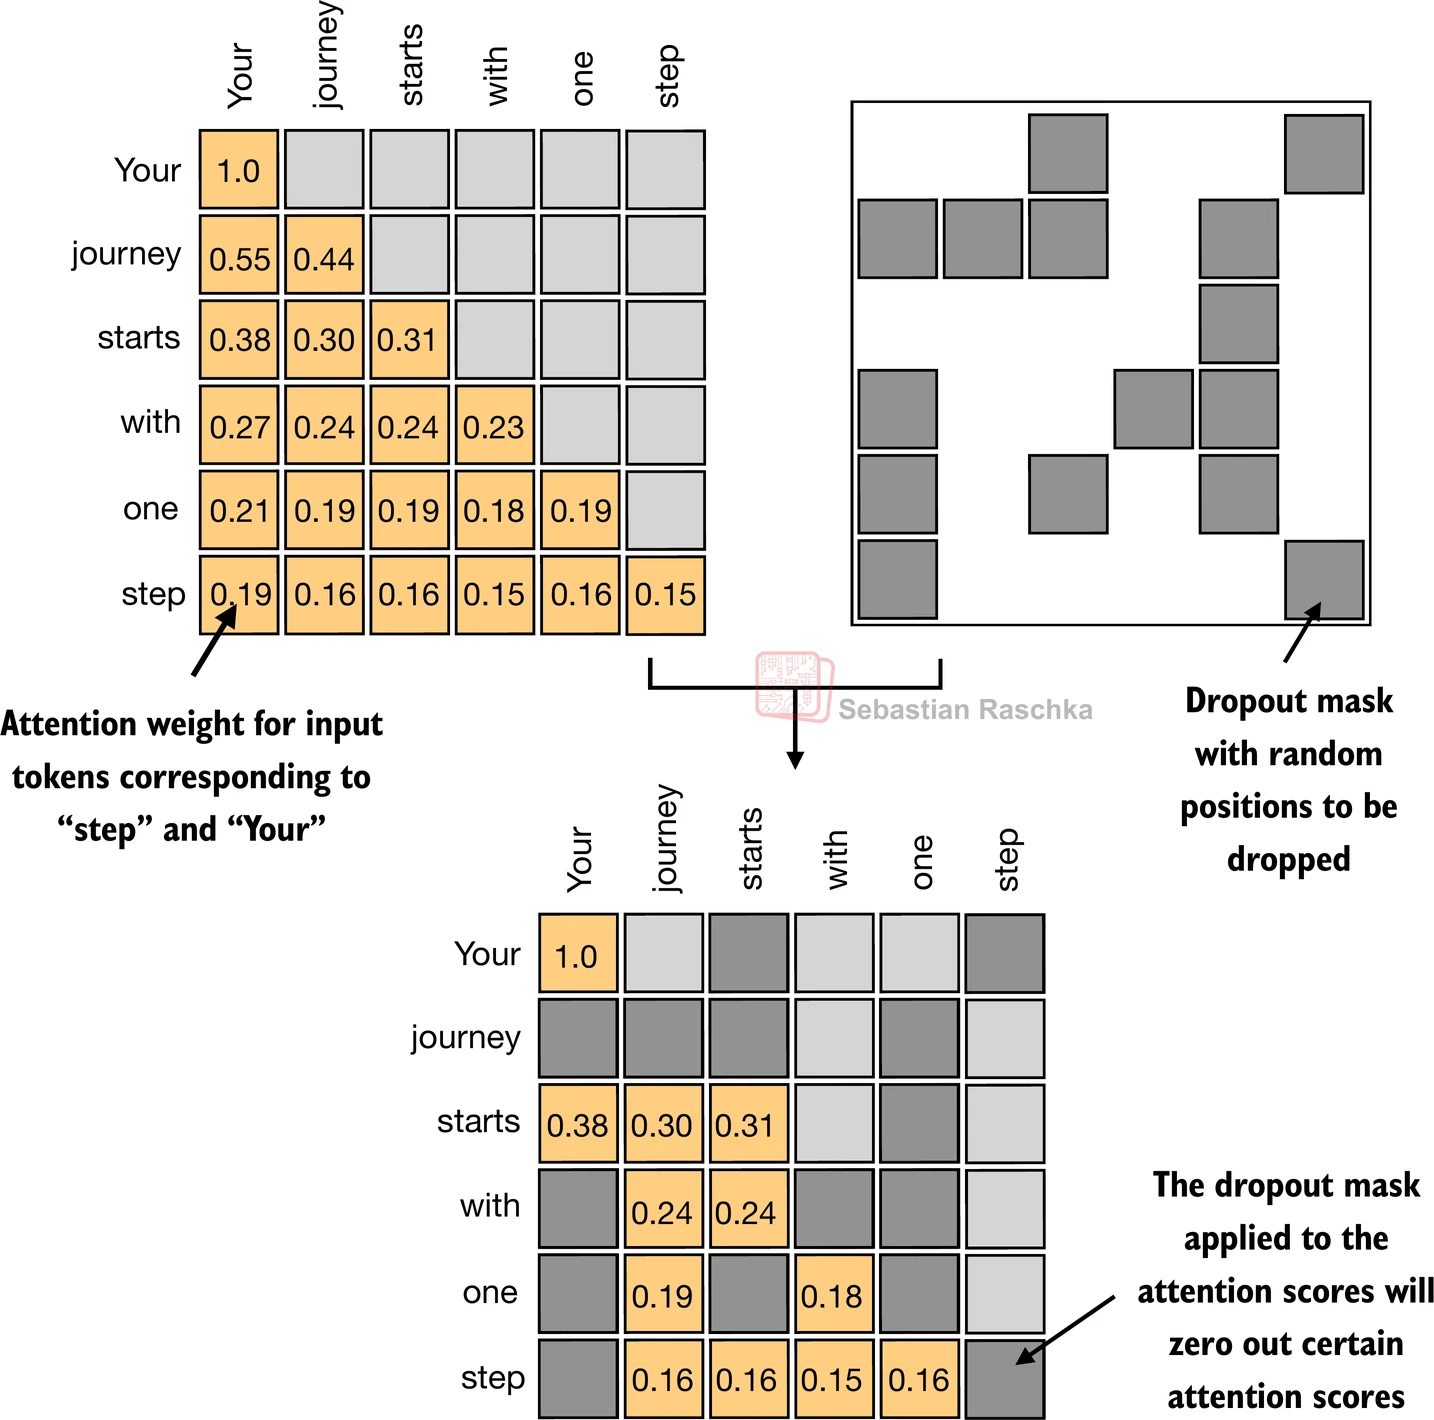

In [ ]:
# 演示 Dropout 的效果：以 50% 的概率随机将元素置 0，
# 剩余保留的元素会按 1/(1-p) 的比例放大，以保持期望值不变
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) # dropout rate of 50%
example = torch.ones(6, 6) # create a matrix of ones

print(dropout(example))

In [ ]:
# 将同样的 dropout 应用到真实的注意力权重矩阵上，
# 训练时对注意力权重做 dropout 可以防止模型过度依赖某些特定的注意力连接
torch.manual_seed(123)
print(dropout(attn_weights))

3.5.3 Implementing a compact causal self-attention class

In [ ]:
# 构造一个 batch：把同一个输入序列复制两份，堆叠出 batch 维度
# inputs: (6, 3) -> batch: (2, 6, 3)，即 (batch_size, num_tokens, d_in)
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) # 2 inputs with 6 tokens each, and each token has embedding dimension 3

In [ ]:
# 支持 batch 输入、内置因果掩码和 dropout 的完整自注意力模块
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        # 用 register_buffer 注册掩码：它不是可训练参数，但会随模型一起移动到 GPU/CPU，并保存在 state_dict 中
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        # x: (b, num_tokens, d_in)，b 为 batch_size
        b, num_tokens, d_in = x.shape # New batch dimension b
        # For inputs where `num_tokens` exceeds `context_length`, this will result in errors
        # in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.
        # keys/queries/values: (b, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # 对最后两个维度做转置再做批量矩阵乘法：
        # queries: (b, num_tokens, d_out) @ keys.transpose(1,2): (b, d_out, num_tokens) -> attn_scores: (b, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        # attn_weights: (b, num_tokens, num_tokens) @ values: (b, num_tokens, d_out) -> context_vec: (b, num_tokens, d_out)
        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)

context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)

context_vecs = ca(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

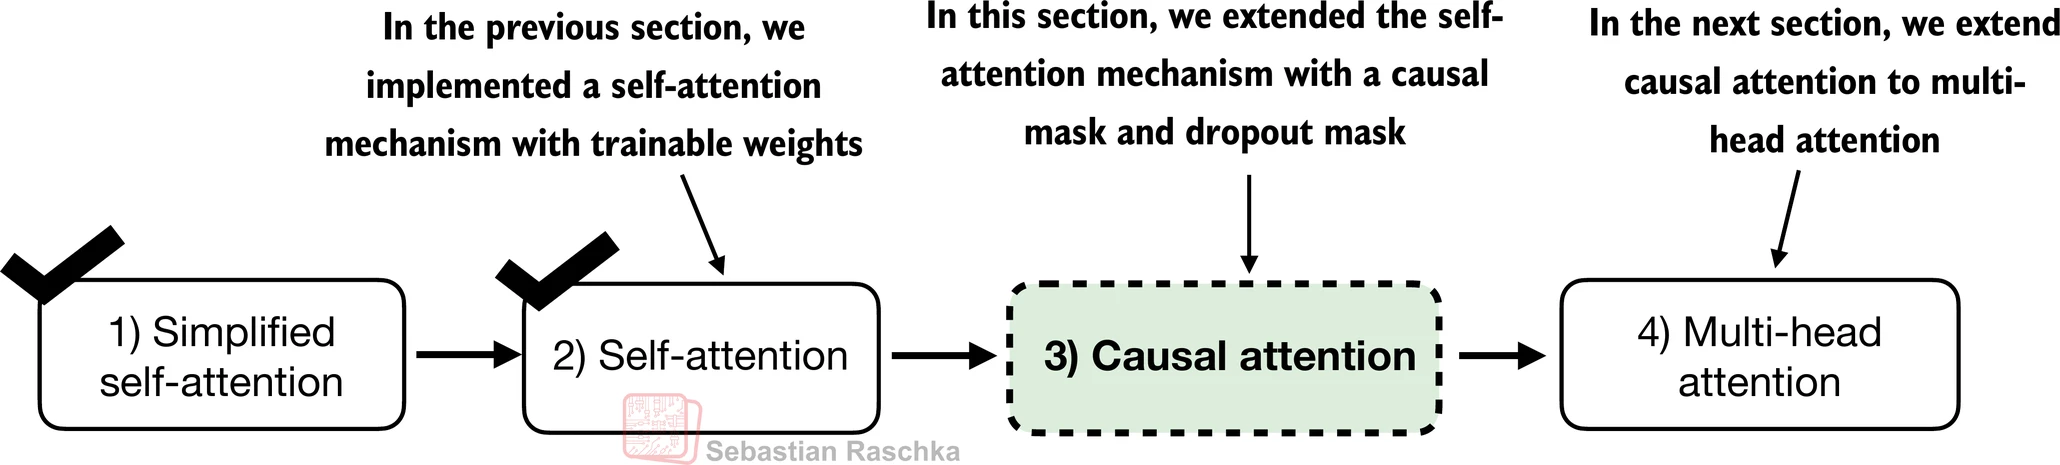

3.6 Extending single-head attention to multi-head attention


3.6.1 Stacking multiple single-head attention layers
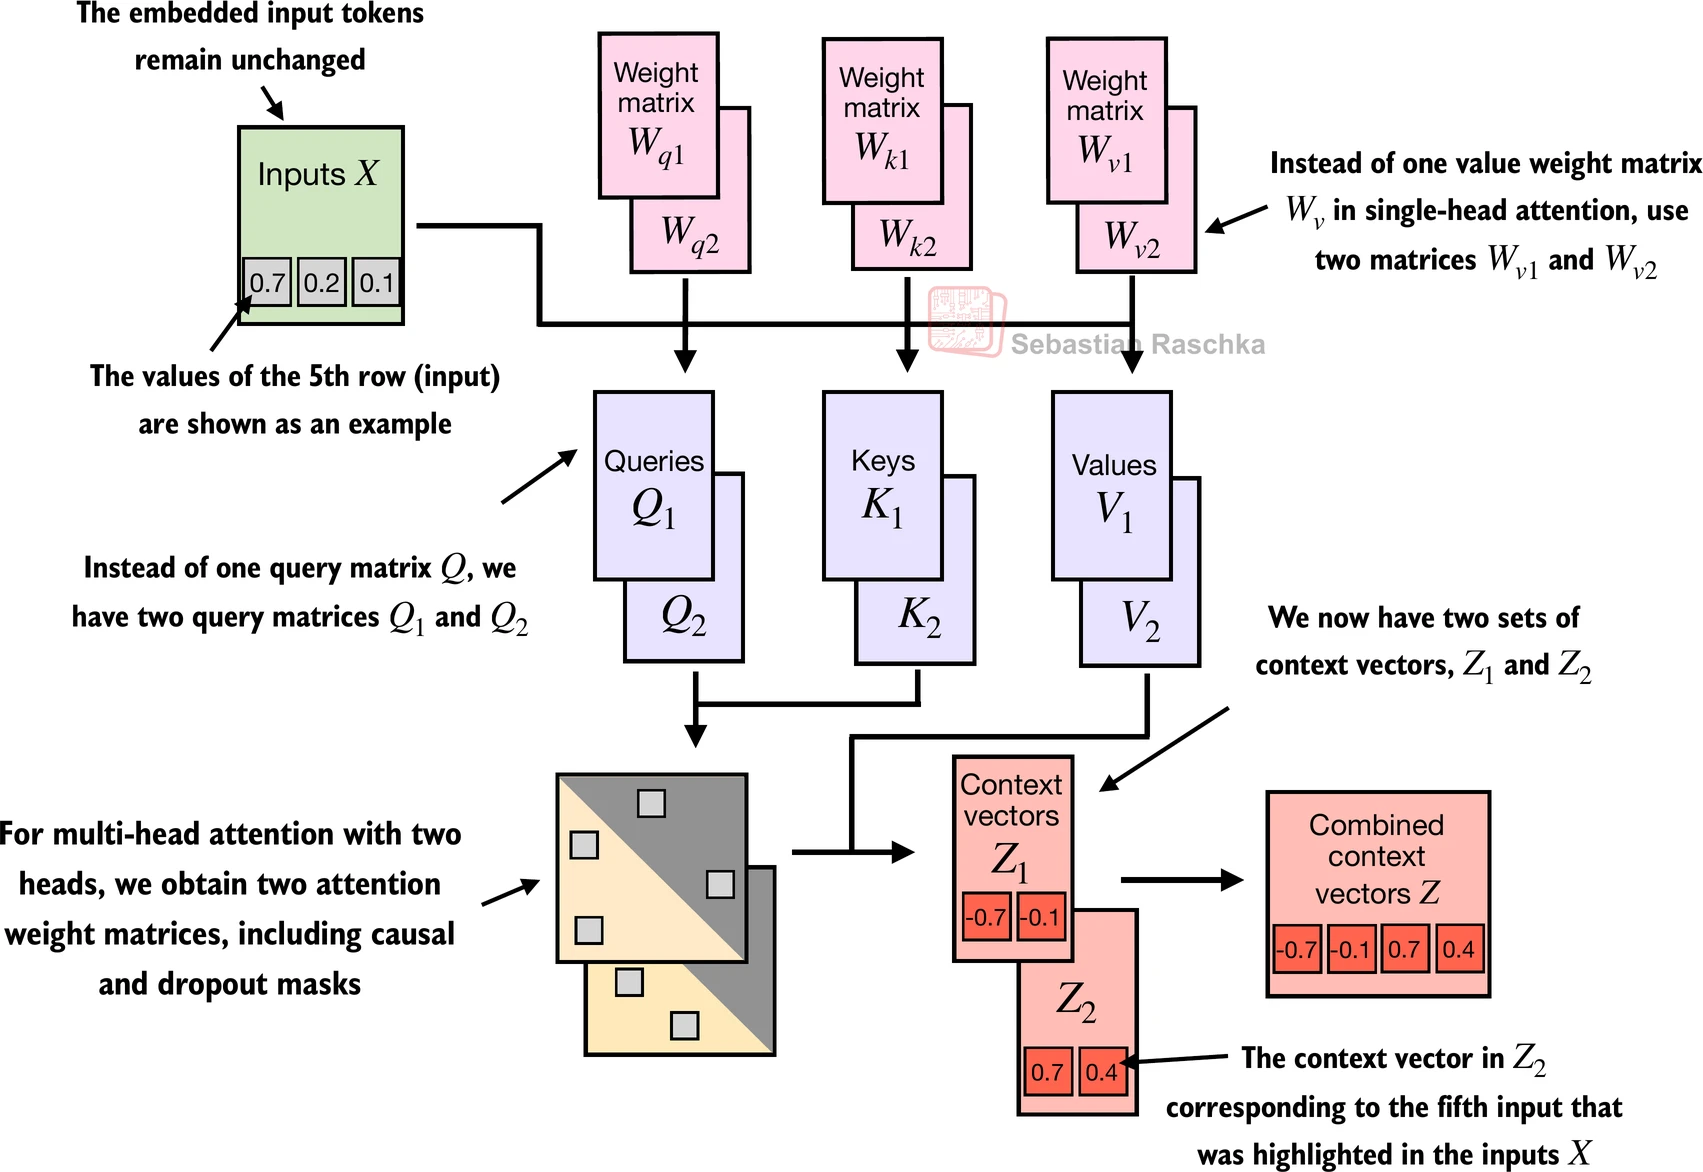
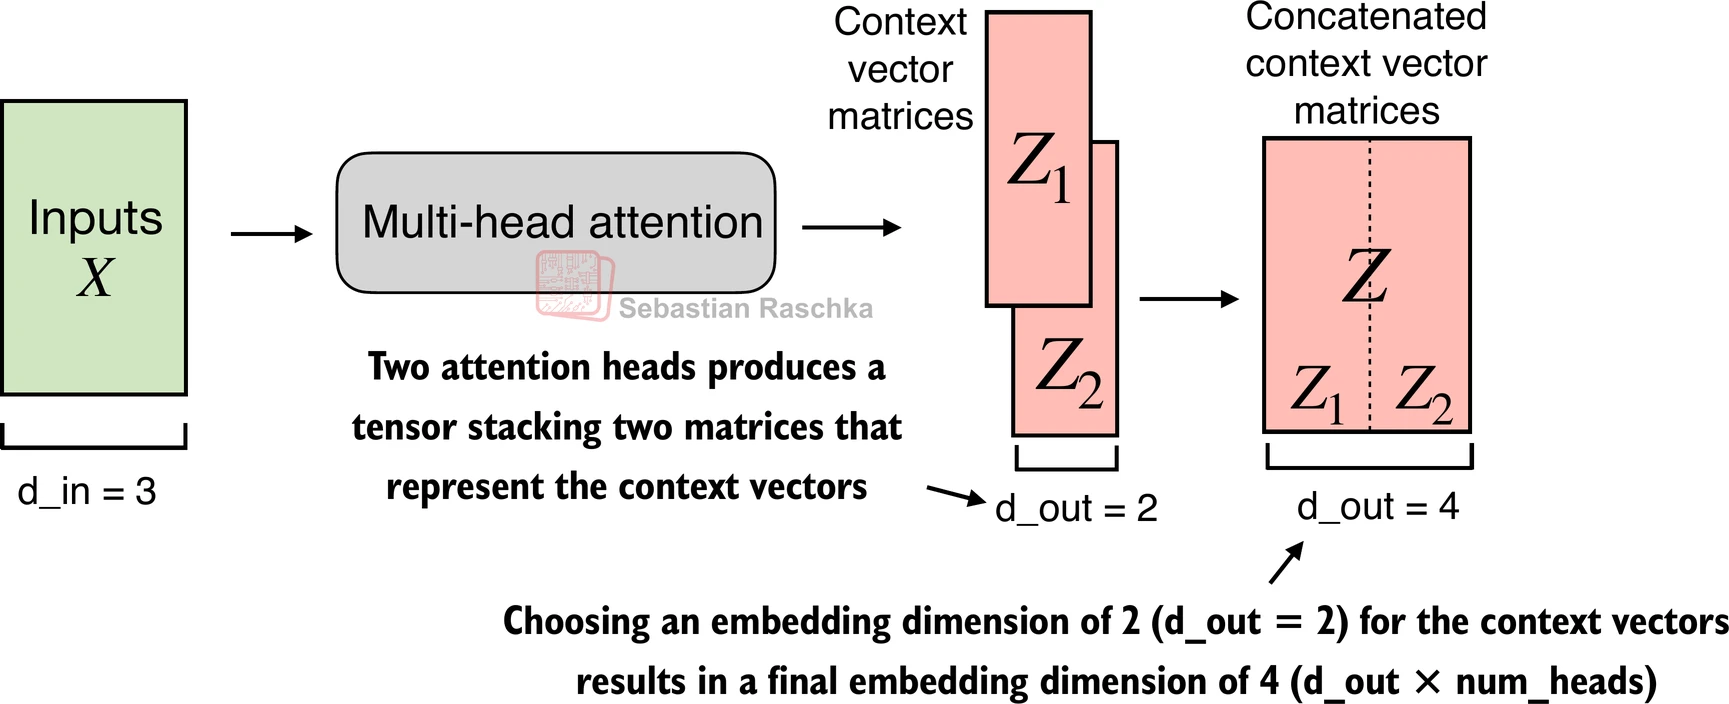

In [ ]:
# 多头注意力（简单实现）：并行跑多个独立的 CausalAttention "头"，
# 再把每个头输出的上下文向量在最后一维拼接起来
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        # 每个 head(x) 输出形状为 (b, num_tokens, d_out)，
        # 沿最后一维拼接 num_heads 个头 -> (b, num_tokens, num_heads * d_out)
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)

context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
# 最终输出维度 = num_heads * d_out = 2 * 2 = 4（每个头输出 2 维，拼接 2 个头）
print("context_vecs.shape:", context_vecs.shape)

3.6.2 Implementing multi-head attention with weight splits

In [ ]:
# 高效实现的多头注意力：使用单个大的 Q/K/V 线性层一次性投影，
# 再通过 reshape（view）把最后一维"拆分"成 (num_heads, head_dim)，从而并行计算所有头，
# 相比 MultiHeadAttentionWrapper（多个独立小头）计算效率更高
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        # 仍然只需要一组 Q/K/V 权重，输出维度为 d_out（= num_heads * head_dim）
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # As in `CausalAttention`, for inputs where `num_tokens` exceeds `context_length`,
        # this will result in errors in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        # 这一步是多头拆分的关键：把 d_out 这一维"拆"成 (num_heads, head_dim) 两维，
        # 数据本身没有任何变化，只是换了一种"看待"方式（reshape 不涉及数据搬动，前提是内存连续）
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        # 把 num_heads 维换到 batch 维之后，这样每个头都可以看作一个独立的 "mini-batch"，
        # 后续矩阵乘法会自动在 num_heads 这一维上并行广播
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        # queries: (b, num_heads, num_tokens, head_dim) @ keys.transpose(2,3): (b, num_heads, head_dim, num_tokens)
        # -> attn_scores: (b, num_heads, num_tokens, num_tokens)，每个头独立计算自己的注意力分数矩阵
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        # 布尔掩码会自动广播到 (b, num_heads, num_tokens, num_tokens)，对每个 batch、每个头都生效
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        # attn_weights: (b, num_heads, num_tokens, num_tokens) @ values: (b, num_heads, num_tokens, head_dim)
        # -> (b, num_heads, num_tokens, head_dim)，再转置回 (b, num_tokens, num_heads, head_dim) 便于后续合并
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        # 多头合并：先用 .contiguous() 保证内存连续（transpose 之后内存不再连续，view 需要连续内存），
        # 再把最后两维 (num_heads, head_dim) 合并回 d_out，形状变为 (b, num_tokens, d_out)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

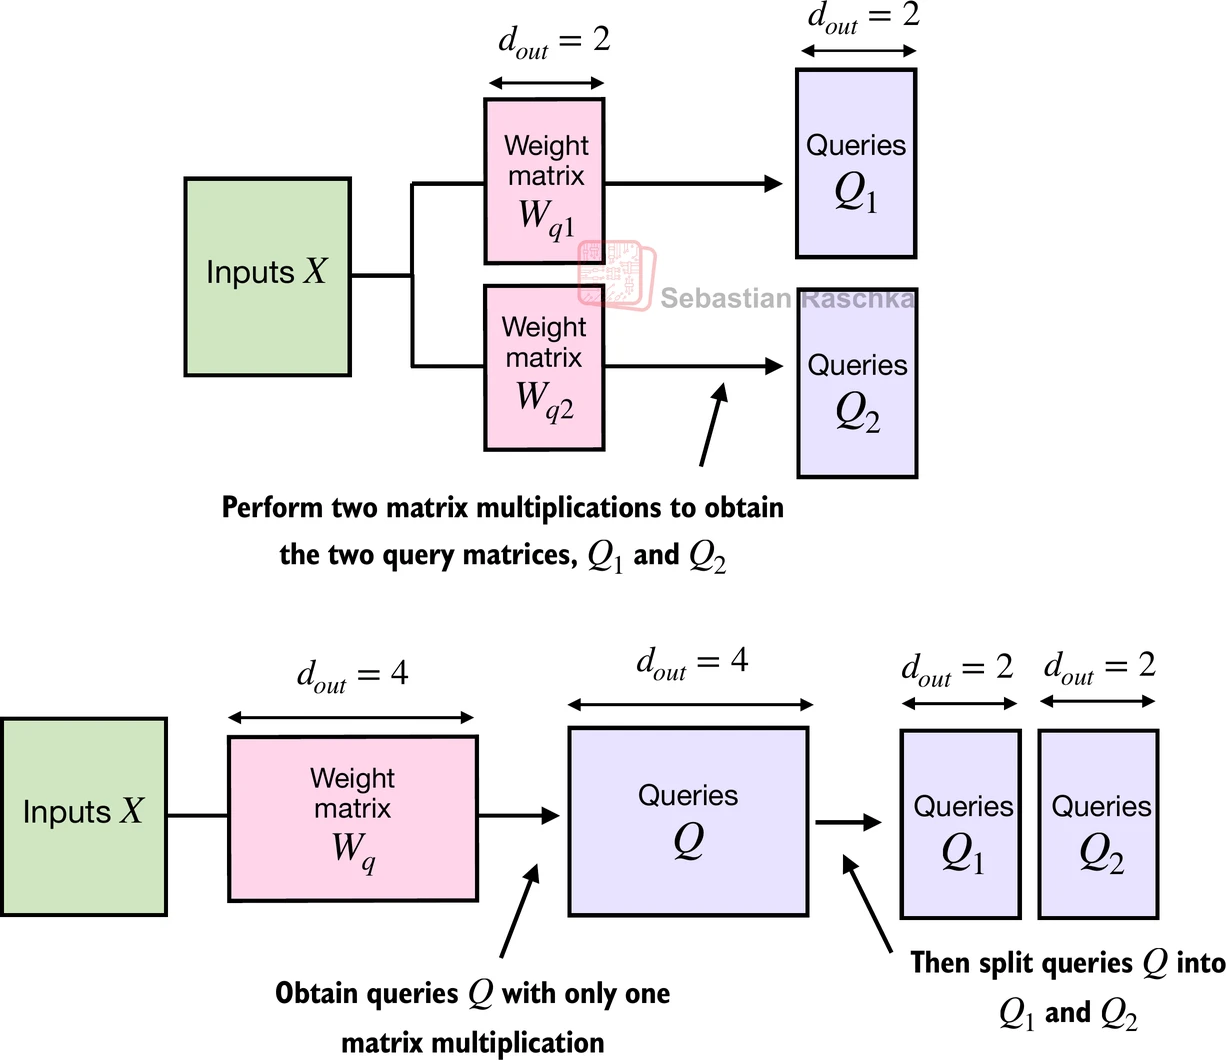

In [ ]:
# 演示：批量矩阵乘法（batched matmul）如何在多头维度上自动并行工作
# a 的形状为 (b=1, num_heads=2, num_tokens=3, head_dim=4)
# (b, num_heads, num_tokens, head_dim) = (1, 2, 3, 4)
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388],
                    [0.7179, 0.7058, 0.9156, 0.4340]],

                   [[0.0772, 0.3565, 0.1479, 0.5331],
                    [0.4066, 0.2318, 0.4545, 0.9737],
                    [0.4606, 0.5159, 0.4220, 0.5786]]]])

# a: (1, 2, 3, 4) @ a.transpose(2,3): (1, 2, 4, 3) -> (1, 2, 3, 3)
# PyTorch 会对前两个维度 (b, num_heads) 做广播，分别对每个头独立做 (3,4)@(4,3) 的矩阵乘法
print(a @ a.transpose(2, 3))

In [ ]:
# 验证上面的批量矩阵乘法等价于对每个头单独取出来做矩阵乘法
first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)

second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)